# BU RISE Wind-Model Comparison Notebook

This notebook compares all active CPU and GPU wind models using the exact common eligible test rows shared by every model.

It supports:

- common wind-speed MAE and correlation;
- circular direction MAE above a configurable wind-speed threshold;
- balanced/hybrid model selection;
- pairwise model comparisons;
- predicted-versus-true scatterplots;
- direction-error distributions;
- direction MAE by wind-speed bin;
- per-flight comparisons;
- representative-flight time series;
- direction-confidence diagnostics.

The notebook automatically excludes archived folders whose names contain terms such as `incomplete`, `failed`, `backup`, or `old`.

## 1. Setup

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "src" / "final_analysis_utils.py").exists() and (candidate / "results" / "scc" / "baseline").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Place this notebook in the project root or a subfolder, "
        "and make sure src/final_analysis_utils.py and results/scc/baseline exist."
    )

PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "results" / "scc" / "baseline"
OUTPUT_DIR = PROJECT_ROOT / "results" / "scc" / "final_analysis"
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from final_analysis_utils import (
    common_frames,
    compute_common_comparison,
    load_all_predictions,
    select_winners,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir:  {RESULTS_DIR}")
print(f"Output dir:   {OUTPUT_DIR}")

Project root: C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models
Results dir:  C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\scc\baseline
Output dir:   C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\scc\final_analysis


## 2. Analysis configuration

In [2]:
EXPECTED_MODELS = 12
DIRECTION_MIN_SPEED = 1.0
SPEED_WEIGHT = 0.50
DIRECTION_WEIGHT = 0.50
RANDOM_SEED = 42

# Change these later for focused plots.
SELECTED_MODEL = None
SELECTED_FLIGHT = None

print(
    f"Expected models: {EXPECTED_MODELS}\n"
    f"Direction metric threshold: true wind speed > {DIRECTION_MIN_SPEED:g} m/s\n"
    f"Balanced weights: speed={SPEED_WEIGHT:.2f}, direction={DIRECTION_WEIGHT:.2f}"
)

Expected models: 12
Direction metric threshold: true wind speed > 1 m/s
Balanced weights: speed=0.50, direction=0.50


## 3. Load all active predictions and recompute common-row metrics

In [3]:
models = load_all_predictions(RESULTS_DIR, expected_models=EXPECTED_MODELS)

comparison, common_keys = compute_common_comparison(
    models,
    direction_min_speed=DIRECTION_MIN_SPEED,
    speed_weight=SPEED_WEIGHT,
    direction_weight=DIRECTION_WEIGHT,
)
selections, finalists = select_winners(comparison)
frames = common_frames(models, common_keys)

print(f"Loaded {len(models)} active models.")
print(f"Exact common eligible rows: {len(common_keys):,}")
print("Models:", ", ".join(sorted(models)))

Loaded 12 active models.
Exact common eligible rows: 65,490
Models: catboost, decision_tree, dummy, extra_trees, lightgbm, lstm, mlp, random_forest, ridge, tcn, transformer, xgboost


## 4. Complete model ranking

In [4]:
ranking_columns = [
    "display_name",
    "hardware",
    "common_n",
    "common_speed_mae_mps",
    "common_speed_rmse_mps",
    "common_speed_r",
    "common_direction_mae_deg_above_threshold",
    "common_direction_median_abs_error_deg_above_threshold",
    "common_direction_p90_abs_error_deg_above_threshold",
    "mean_direction_confidence_above_threshold",
    "balanced_hybrid_score",
    "speed_rank",
    "direction_rank",
    "balanced_rank",
]

ranking = comparison[ranking_columns].sort_values(
    ["balanced_rank", "speed_rank", "direction_rank"]
).reset_index(drop=True)

ranking.style.format({
    "common_n": "{:,.0f}",
    "common_speed_mae_mps": "{:.4f}",
    "common_speed_rmse_mps": "{:.4f}",
    "common_speed_r": "{:.4f}",
    "common_direction_mae_deg_above_threshold": "{:.2f}",
    "common_direction_median_abs_error_deg_above_threshold": "{:.2f}",
    "common_direction_p90_abs_error_deg_above_threshold": "{:.2f}",
    "mean_direction_confidence_above_threshold": "{:.4f}",
    "balanced_hybrid_score": "{:.4f}",
}).background_gradient(
    subset=[
        "common_speed_mae_mps",
        "common_direction_mae_deg_above_threshold",
        "balanced_hybrid_score",
    ],
    cmap="RdYlGn_r",
)

,display_name,hardware,common_n,common_speed_mae_mps,common_speed_rmse_mps,common_speed_r,common_direction_mae_deg_above_threshold,common_direction_median_abs_error_deg_above_threshold,common_direction_p90_abs_error_deg_above_threshold,mean_direction_confidence_above_threshold,balanced_hybrid_score,speed_rank,direction_rank,balanced_rank
0,Extra Trees,cpu,"65,490",0.5231,0.7455,0.9772,20.25,10.86,52.02,0.7736,1.0013,2,2,1
1,CatBoost,cpu,"65,490",0.5369,0.7524,0.9766,21.12,11.61,50.09,0.8219,1.0362,4,4,2
2,XGBoost,cpu,"65,490",0.5222,0.7453,0.9770,21.76,11.31,54.34,0.8106,1.0373,1,6,3
3,Random Forest,cpu,"65,490",0.5367,0.7968,0.9735,21.97,11.16,57.20,0.7831,1.0564,3,7,4
4,LSTM,gpu,"65,490",0.5920,0.8076,0.9734,20.23,10.74,49.21,0.9973,1.0647,6,1,5
5,LightGBM,cpu,"65,490",0.5522,0.7689,0.9755,22.68,12.49,56.47,0.7947,1.0889,5,9,6
6,TCN,gpu,"65,490",0.6237,0.8233,0.9742,21.28,11.77,51.47,1.0046,1.1210,8,5,7
7,MLP,gpu,"65,490",0.6087,0.8388,0.9708,22.18,11.19,57.54,0.8316,1.1306,7,8,8
8,Transformer,gpu,"65,490",0.6794,0.8946,0.9697,20.43,11.50,49.42,1.1104,1.1464,9,3,9
9,Decision Tree,cpu,"65,490",0.7231,1.0646,0.9527,33.63,16.35,98.37,0.9420,1.5173,10,10,10


## 5. Final selections

In [5]:
display(selections)
display(finalists[
    [
        "display_name",
        "roles",
        "common_speed_mae_mps",
        "common_direction_mae_deg_above_threshold",
        "balanced_hybrid_score",
    ]
])

speed_winner = selections.loc[selections["category"] == "best_common_speed", "model"].iloc[0]
direction_winner = selections.loc[selections["category"] == "best_direction_above_threshold", "model"].iloc[0]
balanced_winner = selections.loc[selections["category"] == "best_balanced_hybrid", "model"].iloc[0]

print(f"Best common speed model:         {models[speed_winner].display_name}")
print(f"Best direction model >1 m/s:    {models[direction_winner].display_name}")
print(f"Strongest balanced model:       {models[balanced_winner].display_name}")

,category,model,display_name,metric,value,units,definition
0,best_common_speed,xgboost,XGBoost,common_speed_mae_mps,0.5222,m/s,Lowest speed MAE on the exact common eligible ...
1,best_direction_above_threshold,lstm,LSTM,common_direction_mae_deg_above_threshold,20.2265,degrees,Lowest circular direction MAE on common rows w...
2,best_balanced_hybrid,extra_trees,Extra Trees,balanced_hybrid_score,1.0013,relative score; lower is better,Equal-weight geometric mean of speed-MAE regre...


,display_name,roles,common_speed_mae_mps,common_direction_mae_deg_above_threshold,balanced_hybrid_score
0,Extra Trees,best_balanced_hybrid,0.5231,20.2478,1.0013
1,XGBoost,best_common_speed,0.5222,21.7634,1.0373
2,LSTM,best_direction_above_threshold,0.5920,20.2265,1.0647


Best common speed model:         XGBoost
Best direction model >1 m/s:    LSTM
Strongest balanced model:       Extra Trees


## 6. Speed and direction leaderboard charts

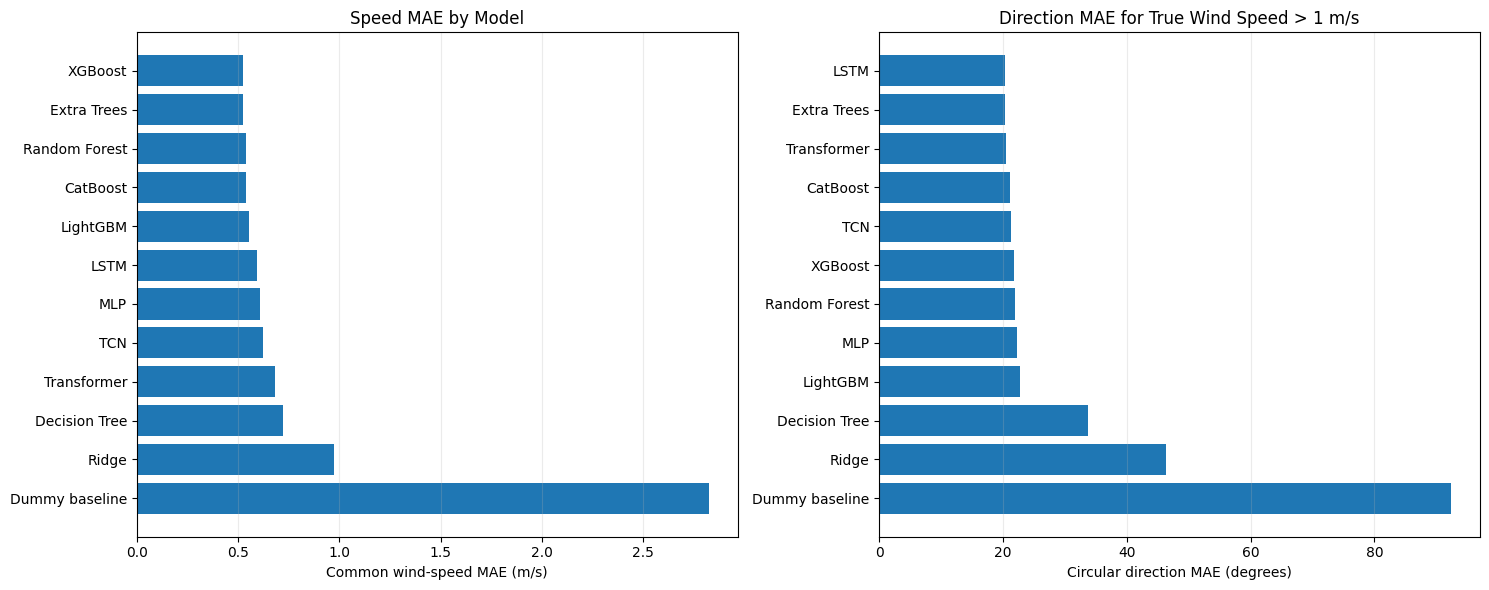

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

speed_order = comparison.sort_values("common_speed_mae_mps", ascending=True)
axes[0].barh(speed_order["display_name"], speed_order["common_speed_mae_mps"])
axes[0].invert_yaxis()
axes[0].set_xlabel("Common wind-speed MAE (m/s)")
axes[0].set_title("Speed MAE by Model")
axes[0].grid(axis="x", alpha=0.25)

direction_metric = "common_direction_mae_deg_above_threshold"
direction_order = comparison.sort_values(direction_metric, ascending=True)
axes[1].barh(direction_order["display_name"], direction_order[direction_metric])
axes[1].invert_yaxis()
axes[1].set_xlabel("Circular direction MAE (degrees)")
axes[1].set_title(f"Direction MAE for True Wind Speed > {DIRECTION_MIN_SPEED:g} m/s")
axes[1].grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

## 7. Interactive model selector

In [7]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    model_options = [(models[name].display_name, name) for name in sorted(models)]
    model_dropdown = widgets.Dropdown(
        options=model_options,
        value=balanced_winner,
        description="Model:",
        layout=widgets.Layout(width="420px"),
    )
    display(model_dropdown)
    print("Use model_dropdown.value in the cells below.")
except ImportError:
    model_dropdown = None
    print("ipywidgets is not installed. Set SELECTED_MODEL manually in the configuration cell.")

Dropdown(description='Model:', index=3, layout=Layout(width='420px'), options=(('CatBoost', 'catboost'), ('Dec…

Use model_dropdown.value in the cells below.


## 8. Predicted versus true wind speed

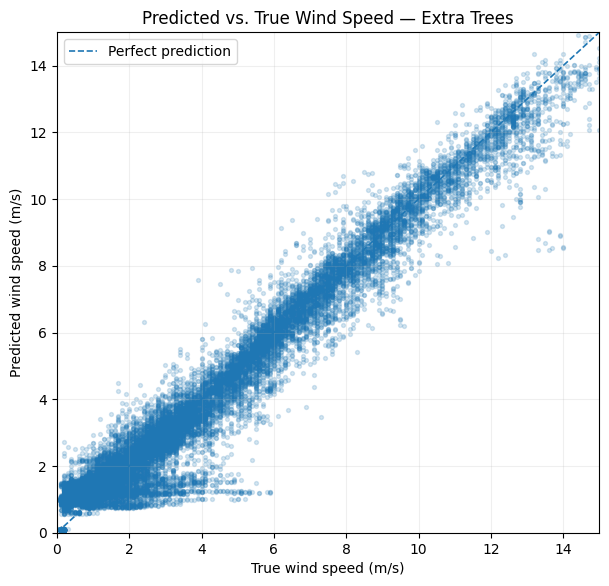

In [8]:
def current_model(default: str = balanced_winner) -> str:
    if model_dropdown is not None:
        return model_dropdown.value
    return SELECTED_MODEL or default

model_name = current_model(speed_winner)
frame = frames[model_name].dropna(subset=["true_speed", "pred_speed"]).copy()

max_points = 20_000
plot_frame = frame if len(frame) <= max_points else frame.sample(max_points, random_state=RANDOM_SEED)
lower = float(min(plot_frame["true_speed"].min(), plot_frame["pred_speed"].min()))
upper = float(max(plot_frame["true_speed"].quantile(0.995), plot_frame["pred_speed"].quantile(0.995)))

fig, ax = plt.subplots(figsize=(7, 6.5))
ax.scatter(plot_frame["true_speed"], plot_frame["pred_speed"], s=8, alpha=0.18, rasterized=True)
ax.plot([lower, upper], [lower, upper], linestyle="--", linewidth=1.2, label="Perfect prediction")
ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_xlabel("True wind speed (m/s)")
ax.set_ylabel("Predicted wind speed (m/s)")
ax.set_title(f"Predicted vs. True Wind Speed — {models[model_name].display_name}")
ax.grid(alpha=0.2)
ax.legend()
plt.show()

## 9. Direction-error distribution across all models

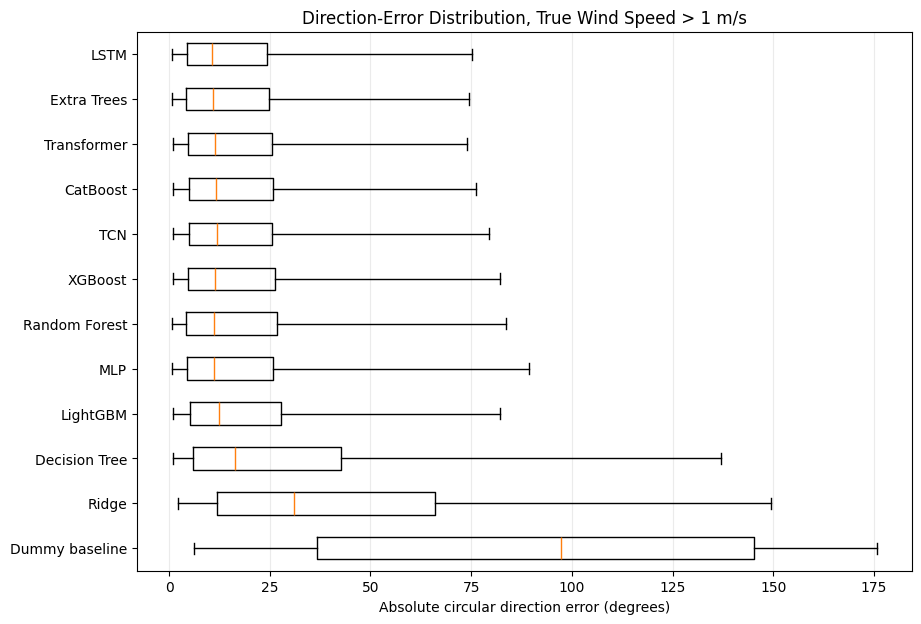

In [9]:
order = comparison.sort_values(
    "common_direction_mae_deg_above_threshold"
)["model"].tolist()

arrays = [
    frames[model].loc[
        frames[model]["true_speed"] > DIRECTION_MIN_SPEED,
        "abs_direction_error",
    ].dropna().to_numpy()
    for model in order
]
labels = [models[model].display_name for model in order]

fig, ax = plt.subplots(figsize=(10, 7))
ax.boxplot(arrays, vert=False, tick_labels=labels, whis=(5, 95), showfliers=False)
ax.invert_yaxis()
ax.set_xlabel("Absolute circular direction error (degrees)")
ax.set_title(f"Direction-Error Distribution, True Wind Speed > {DIRECTION_MIN_SPEED:g} m/s")
ax.grid(axis="x", alpha=0.25)
plt.show()

## 10. Direction MAE by wind-speed bin

,model,display_name,speed_bin,direction_mae_deg,n
0,extra_trees,Extra Trees,0–0.5,75.7067,3174
1,extra_trees,Extra Trees,0.5–1,75.2091,4782
2,extra_trees,Extra Trees,1–2,44.9904,10547
3,extra_trees,Extra Trees,2–4,24.2152,16729
4,extra_trees,Extra Trees,4–6,13.5256,10367


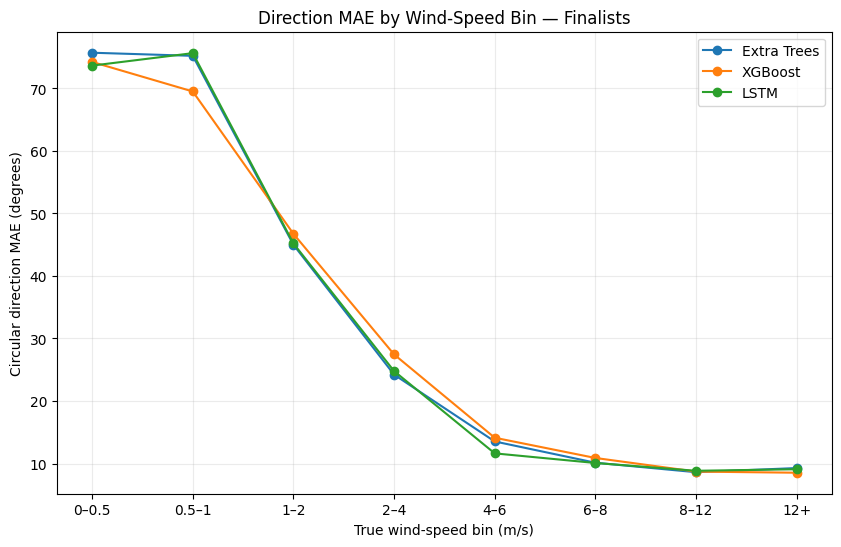

In [10]:
speed_edges = [0.0, 0.5, 1.0, 2.0, 4.0, 6.0, 8.0, 12.0, np.inf]
speed_labels = ["0–0.5", "0.5–1", "1–2", "2–4", "4–6", "6–8", "8–12", "12+"]

rows = []
for model_name, model_data in frames.items():
    temp = model_data.copy()
    temp["speed_bin"] = pd.cut(
        temp["true_speed"],
        bins=speed_edges,
        labels=speed_labels,
        right=False,
        include_lowest=True,
    )
    grouped = temp.groupby("speed_bin", observed=False)["abs_direction_error"].agg(["mean", "count"])
    for speed_bin, values in grouped.iterrows():
        rows.append({
            "model": model_name,
            "display_name": models[model_name].display_name,
            "speed_bin": speed_bin,
            "direction_mae_deg": values["mean"],
            "n": int(values["count"]),
        })

direction_by_bin = pd.DataFrame(rows)
display(direction_by_bin.head())

fig, ax = plt.subplots(figsize=(10, 6))
for model_name in finalists["model"]:
    subset = (
        direction_by_bin[direction_by_bin["model"] == model_name]
        .set_index("speed_bin")
        .reindex(speed_labels)
    )
    y = subset["direction_mae_deg"].where(subset["n"] >= 30)
    ax.plot(speed_labels, y, marker="o", linewidth=1.5, label=models[model_name].display_name)

ax.set_xlabel("True wind-speed bin (m/s)")
ax.set_ylabel("Circular direction MAE (degrees)")
ax.set_title("Direction MAE by Wind-Speed Bin — Finalists")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## 11. Pairwise comparison of any two models

In [11]:
def pairwise_summary(model_a: str, model_b: str) -> pd.DataFrame:
    a = frames[model_a][["row_key", "abs_speed_error", "abs_direction_error", "true_speed"]].copy()
    b = frames[model_b][["row_key", "abs_speed_error", "abs_direction_error"]].copy()
    merged = a.merge(b, on="row_key", suffixes=("_a", "_b"), validate="one_to_one")

    direction_mask = merged["true_speed"] > DIRECTION_MIN_SPEED
    return pd.DataFrame({
        "metric": [
            "Speed MAE",
            f"Direction MAE > {DIRECTION_MIN_SPEED:g} m/s",
            "Rows where A has lower speed error",
            "Rows where A has lower direction error",
        ],
        models[model_a].display_name: [
            merged["abs_speed_error_a"].mean(),
            merged.loc[direction_mask, "abs_direction_error_a"].mean(),
            (merged["abs_speed_error_a"] < merged["abs_speed_error_b"]).mean(),
            (
                merged.loc[direction_mask, "abs_direction_error_a"]
                < merged.loc[direction_mask, "abs_direction_error_b"]
            ).mean(),
        ],
        models[model_b].display_name: [
            merged["abs_speed_error_b"].mean(),
            merged.loc[direction_mask, "abs_direction_error_b"].mean(),
            (merged["abs_speed_error_b"] < merged["abs_speed_error_a"]).mean(),
            (
                merged.loc[direction_mask, "abs_direction_error_b"]
                < merged.loc[direction_mask, "abs_direction_error_a"]
            ).mean(),
        ],
    })

MODEL_A = speed_winner
MODEL_B = balanced_winner if balanced_winner != MODEL_A else direction_winner
pairwise_summary(MODEL_A, MODEL_B)

,metric,XGBoost,Extra Trees
0,Speed MAE,0.5222,0.5231
1,Direction MAE > 1 m/s,21.7634,20.2478
2,Rows where A has lower speed error,0.5029,0.4971
3,Rows where A has lower direction error,0.4525,0.5475


## 12. Per-flight finalist comparison

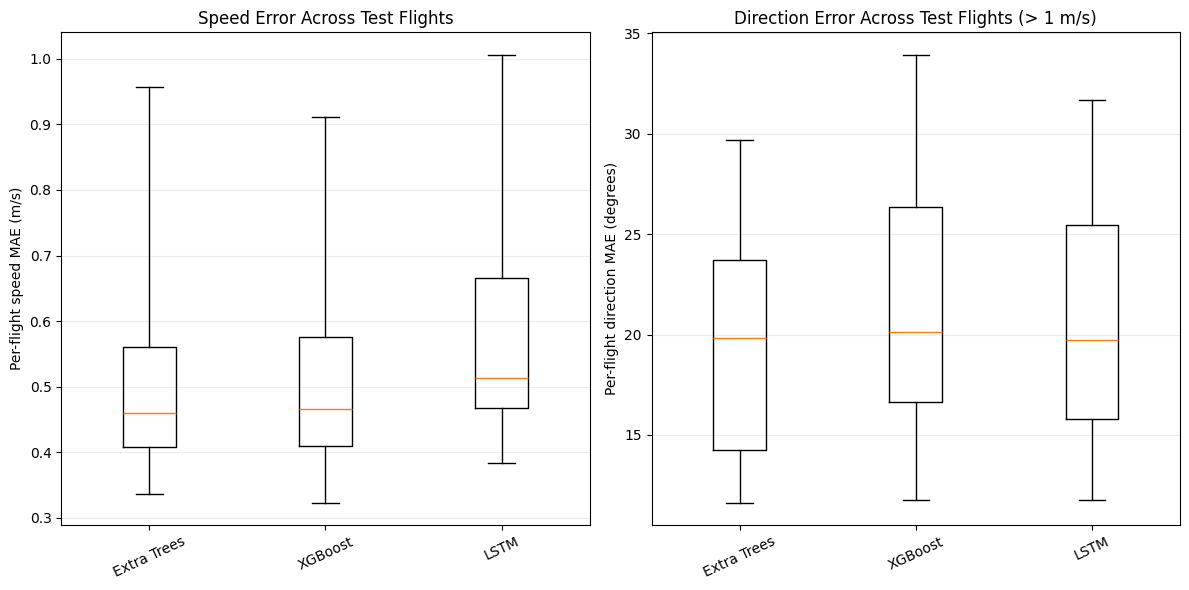

In [12]:
def per_flight_metrics(frame: pd.DataFrame) -> pd.DataFrame:
    speed = frame.groupby("group_id").agg(
        n=("row_key", "size"),
        speed_mae_mps=("abs_speed_error", "mean"),
    )
    direction = (
        frame[frame["true_speed"] > DIRECTION_MIN_SPEED]
        .groupby("group_id")
        .agg(
            direction_n=("row_key", "size"),
            direction_mae_deg=("abs_direction_error", "mean"),
        )
    )
    return speed.join(direction, how="left").reset_index()

flight_tables = {
    model_name: per_flight_metrics(frames[model_name])
    for model_name in finalists["model"]
}

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
labels = [models[name].display_name for name in finalists["model"]]

axes[0].boxplot(
    [flight_tables[name]["speed_mae_mps"].dropna().to_numpy() for name in finalists["model"]],
    tick_labels=labels,
    whis=(5, 95),
    showfliers=False,
)
axes[0].set_ylabel("Per-flight speed MAE (m/s)")
axes[0].set_title("Speed Error Across Test Flights")
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(axis="y", alpha=0.25)

axes[1].boxplot(
    [flight_tables[name]["direction_mae_deg"].dropna().to_numpy() for name in finalists["model"]],
    tick_labels=labels,
    whis=(5, 95),
    showfliers=False,
)
axes[1].set_ylabel("Per-flight direction MAE (degrees)")
axes[1].set_title(f"Direction Error Across Test Flights (> {DIRECTION_MIN_SPEED:g} m/s)")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 13. Find flights where models differ most

In [13]:
model_a = speed_winner
model_b = balanced_winner if balanced_winner != model_a else direction_winner

a = flight_tables[model_a][["group_id", "n", "speed_mae_mps", "direction_mae_deg"]]
b = flight_tables[model_b][["group_id", "speed_mae_mps", "direction_mae_deg"]]
flight_difference = a.merge(b, on="group_id", suffixes=("_a", "_b"), validate="one_to_one")
flight_difference["speed_mae_difference_a_minus_b"] = (
    flight_difference["speed_mae_mps_a"] - flight_difference["speed_mae_mps_b"]
)
flight_difference["direction_mae_difference_a_minus_b"] = (
    flight_difference["direction_mae_deg_a"] - flight_difference["direction_mae_deg_b"]
)

print(f"A = {models[model_a].display_name}")
print(f"B = {models[model_b].display_name}")
display(
    flight_difference.sort_values(
        "speed_mae_difference_a_minus_b",
        key=lambda series: series.abs(),
        ascending=False,
    ).head(15)
)

A = XGBoost
B = Extra Trees


,group_id,n,speed_mae_mps_a,direction_mae_deg_a,speed_mae_mps_b,direction_mae_deg_b,speed_mae_difference_a_minus_b,direction_mae_difference_a_minus_b
14,DJI_primary::171,853,0.8142,26.3871,0.4688,23.5965,0.3454,2.7906
6,DJI_primary::129,1219,1.1575,21.9683,1.3133,21.7059,-0.1558,0.2624
36,DJI_primary::253,992,0.4097,18.2803,0.5097,21.1013,-0.1001,-2.8210
49,DJI_primary::87,1642,0.6080,26.3759,0.5210,24.1293,0.0869,2.2466
37,DJI_primary::256,1121,0.4144,13.2420,0.3426,12.3585,0.0718,0.8835
38,DJI_primary::260,1603,0.4996,15.8521,0.4329,14.5335,0.0668,1.3186
15,DJI_primary::173,1548,0.4784,34.2652,0.4121,28.5240,0.0663,5.7412
2,DJI_primary::116,873,0.9483,29.9327,1.0144,23.4817,-0.0661,6.4510
29,DJI_primary::222,921,0.3723,24.8224,0.4275,29.6945,-0.0552,-4.8721
39,DJI_primary::263,1561,0.3234,20.1117,0.3776,18.3862,-0.0542,1.7255


## 14. Representative-flight time series

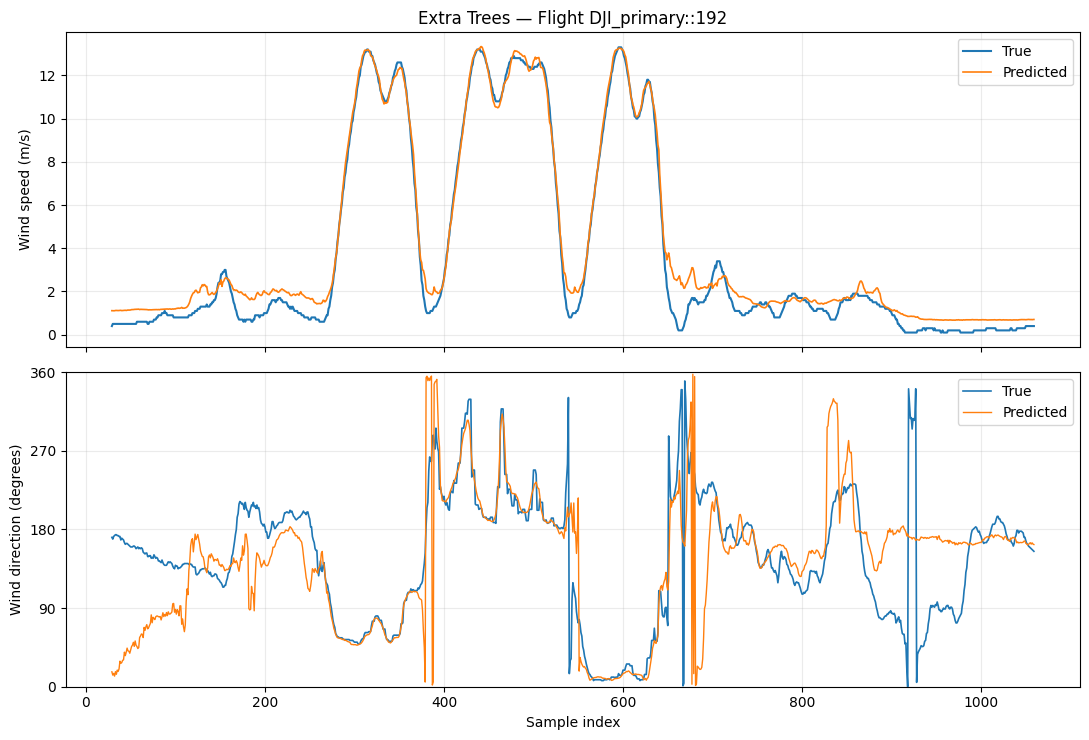

In [14]:
def choose_representative_flight(model_name: str, min_rows: int = 100) -> str:
    metrics = per_flight_metrics(frames[model_name])
    eligible = metrics[(metrics["n"] >= min_rows) & metrics["direction_mae_deg"].notna()].copy()
    if eligible.empty:
        eligible = metrics.dropna(subset=["direction_mae_deg"]).copy()

    speed_median = eligible["speed_mae_mps"].median()
    direction_median = eligible["direction_mae_deg"].median()
    eligible["distance_from_median"] = (
        (eligible["speed_mae_mps"] - speed_median).abs() / max(speed_median, 1e-9)
        + (eligible["direction_mae_deg"] - direction_median).abs() / max(direction_median, 1e-9)
    )
    return str(
        eligible.sort_values(["distance_from_median", "n"], ascending=[True, False])
        .iloc[0]["group_id"]
    )

model_name = current_model(balanced_winner)
group_id = SELECTED_FLIGHT or choose_representative_flight(model_name)
flight = frames[model_name][frames[model_name]["group_id"].astype(str) == str(group_id)].copy()
flight = flight.sort_values("sample_index")

elapsed = pd.to_numeric(flight["elapsed_s"], errors="coerce")
if elapsed.notna().sum() >= 2 and elapsed.nunique(dropna=True) >= 2:
    x = elapsed.to_numpy(dtype=float)
    x_label = "Elapsed time (s)"
else:
    x = pd.to_numeric(flight["sample_index"], errors="coerce").to_numpy(dtype=float)
    x_label = "Sample index"

fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)

axes[0].plot(x, flight["true_speed"], linewidth=1.5, label="True")
axes[0].plot(x, flight["pred_speed"], linewidth=1.2, label="Predicted")
axes[0].set_ylabel("Wind speed (m/s)")
axes[0].set_title(f"{models[model_name].display_name} — Flight {group_id}")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(x, flight["true_angle"], linewidth=1.2, label="True")
axes[1].plot(x, flight["pred_angle"], linewidth=1.0, label="Predicted")
axes[1].set_xlabel(x_label)
axes[1].set_ylabel("Wind direction (degrees)")
axes[1].set_ylim(0, 360)
axes[1].set_yticks([0, 90, 180, 270, 360])
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

## 15. Direction confidence versus direction error

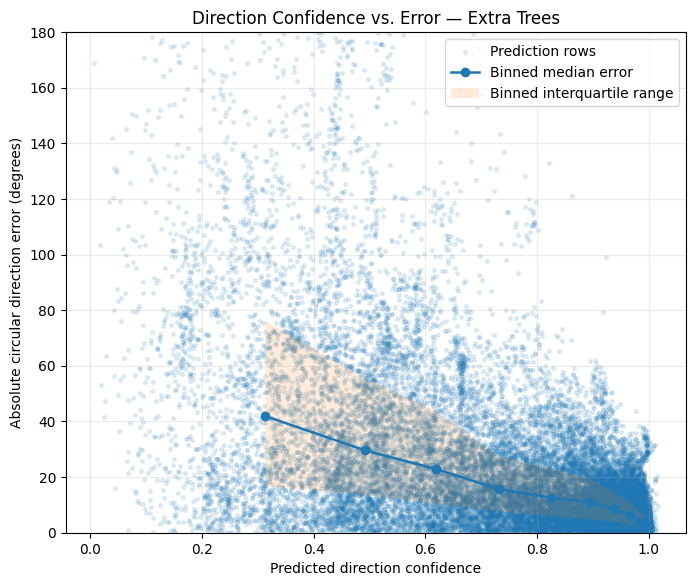

,confidence,median_error,q25_error,q75_error,n
0,0.3134,41.9550,16.6951,76.2450,5643
1,0.4922,29.5973,13.5712,55.6170,5642
2,0.6199,22.8469,10.5243,43.7117,5642
3,0.7325,15.6622,7.6433,27.3479,5642
4,0.8245,12.6486,5.8991,23.2420,5642
5,0.8955,10.9364,4.8457,19.3229,5642
6,0.9394,8.6613,3.9636,14.4809,5642
7,0.9658,6.2511,2.7780,11.3300,5642
8,0.9826,3.9159,1.7251,7.6020,5642
9,0.9933,3.2987,1.5165,6.3938,5642


In [15]:
model_name = current_model(balanced_winner)
confidence_frame = frames[model_name][
    (frames[model_name]["true_speed"] > DIRECTION_MIN_SPEED)
    & frames[model_name]["confidence"].notna()
    & frames[model_name]["abs_direction_error"].notna()
].copy()

if confidence_frame.empty:
    print(f"{models[model_name].display_name} has no finite direction-confidence values.")
else:
    max_points = 30_000
    plot_frame = (
        confidence_frame
        if len(confidence_frame) <= max_points
        else confidence_frame.sample(max_points, random_state=RANDOM_SEED)
    )

    quantile_edges = np.unique(
        confidence_frame["confidence"].quantile(np.linspace(0, 1, 11)).to_numpy()
    )
    if len(quantile_edges) >= 3:
        confidence_frame["confidence_bin"] = pd.cut(
            confidence_frame["confidence"],
            bins=quantile_edges,
            include_lowest=True,
            duplicates="drop",
        )
        confidence_bins = (
            confidence_frame.groupby("confidence_bin", observed=True)
            .agg(
                confidence=("confidence", "median"),
                median_error=("abs_direction_error", "median"),
                q25_error=("abs_direction_error", lambda x: x.quantile(0.25)),
                q75_error=("abs_direction_error", lambda x: x.quantile(0.75)),
                n=("abs_direction_error", "size"),
            )
            .reset_index(drop=True)
        )
    else:
        confidence_bins = pd.DataFrame()

    fig, ax = plt.subplots(figsize=(8, 6.5))
    ax.scatter(
        plot_frame["confidence"],
        plot_frame["abs_direction_error"],
        s=7,
        alpha=0.12,
        rasterized=True,
        label="Prediction rows",
    )
    if not confidence_bins.empty:
        ax.plot(
            confidence_bins["confidence"],
            confidence_bins["median_error"],
            marker="o",
            linewidth=1.8,
            label="Binned median error",
        )
        ax.fill_between(
            confidence_bins["confidence"].to_numpy(dtype=float),
            confidence_bins["q25_error"].to_numpy(dtype=float),
            confidence_bins["q75_error"].to_numpy(dtype=float),
            alpha=0.15,
            label="Binned interquartile range",
        )

    ax.set_xlabel("Predicted direction confidence")
    ax.set_ylabel("Absolute circular direction error (degrees)")
    ax.set_title(f"Direction Confidence vs. Error — {models[model_name].display_name}")
    ax.set_ylim(0, 180)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

    display(confidence_bins)

In [16]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import clear_output, display

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError(
        "This cell needs ipywidgets. In Anaconda Prompt run: conda install ipywidgets"
    ) from exc

if "models" not in globals() or "frames" not in globals():
    raise RuntimeError(
        "Run the notebook's setup, loading, and common-metric cells before this cell."
    )


def _common_flights(selected_models: list[str]) -> list[tuple[str, int]]:
    """Return flights shared by all selected models, ordered by row count."""
    if not selected_models:
        return []

    common = None
    for model_name in selected_models:
        counts = frames[model_name].groupby("group_id").size()
        flight_ids = set(counts.index.astype(str))
        common = flight_ids if common is None else common.intersection(flight_ids)

    first_counts = (
        frames[selected_models[0]]
        .assign(group_id=lambda x: x["group_id"].astype(str))
        .groupby("group_id")
        .size()
    )
    return sorted(
        [(flight_id, int(first_counts.get(flight_id, 0))) for flight_id in common],
        key=lambda item: (-item[1], item[0]),
    )


def _aligned_flight_frame(selected_models: list[str], flight_id: str) -> pd.DataFrame:
    """Align one flight across models by the common row key."""
    first = selected_models[0]
    base = frames[first].loc[
        frames[first]["group_id"].astype(str) == str(flight_id),
        ["row_key", "sample_index", "true_speed", "true_angle"],
    ].copy()

    for model_name in selected_models:
        pred = frames[model_name].loc[
            frames[model_name]["group_id"].astype(str) == str(flight_id),
            ["row_key", "pred_speed", "pred_angle", "speed_error", "direction_error"],
        ].copy()
        pred = pred.rename(columns={
            "pred_speed": f"pred_speed__{model_name}",
            "pred_angle": f"pred_angle__{model_name}",
            "speed_error": f"speed_error__{model_name}",
            "direction_error": f"direction_error__{model_name}",
        })
        base = base.merge(pred, on="row_key", how="inner", validate="one_to_one")

    return base.sort_values(["sample_index", "row_key"]).reset_index(drop=True)


def plot_model_sequence_comparison(
    selected_models: list[str],
    flight_id: str,
    max_points: int = 1500,
):
    """Compare observed wind with one or more models along a flight sequence."""
    if not selected_models:
        raise ValueError("Select at least one model.")

    flight = _aligned_flight_frame(selected_models, flight_id)
    if flight.empty:
        raise ValueError(f"No aligned rows found for flight {flight_id!r}.")

    if len(flight) > max_points:
        positions = np.unique(
            np.rint(np.linspace(0, len(flight) - 1, max_points)).astype(int)
        )
        flight = flight.iloc[positions].copy()

    x = flight["sample_index"]
    fig = make_subplots(
        rows=4,
        cols=1,
        shared_xaxes=True,
        subplot_titles=(
            "Wind speed",
            "Wind direction-from",
            "Speed prediction error",
            "Circular direction error",
        ),
        vertical_spacing=0.065,
    )

    fig.add_trace(
        go.Scatter(
            x=x,
            y=flight["true_speed"],
            mode="lines",
            name="Observed speed",
            line={"width": 2.5},
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=x,
            y=flight["true_angle"],
            mode="lines",
            name="Observed direction",
            line={"width": 2.5},
        ),
        row=2,
        col=1,
    )

    summary_rows = []
    for model_name in selected_models:
        label = models[model_name].display_name

        fig.add_trace(
            go.Scatter(
                x=x,
                y=flight[f"pred_speed__{model_name}"],
                mode="lines",
                name=f"{label} speed",
                line={"dash": "dash"},
            ),
            row=1,
            col=1,
        )
        fig.add_trace(
            go.Scatter(
                x=x,
                y=flight[f"pred_angle__{model_name}"],
                mode="lines",
                name=f"{label} direction",
                line={"dash": "dash"},
            ),
            row=2,
            col=1,
        )
        fig.add_trace(
            go.Scatter(
                x=x,
                y=flight[f"speed_error__{model_name}"],
                mode="lines",
                name=f"{label} speed error",
            ),
            row=3,
            col=1,
        )
        fig.add_trace(
            go.Scatter(
                x=x,
                y=flight[f"direction_error__{model_name}"],
                mode="lines",
                name=f"{label} direction error",
            ),
            row=4,
            col=1,
        )

        direction_mask = flight["true_speed"] > DIRECTION_MIN_SPEED
        summary_rows.append({
            "model": label,
            "flight_rows_plotted": len(flight),
            "flight_speed_mae_mps": flight[f"speed_error__{model_name}"].abs().mean(),
            f"flight_direction_mae_deg_above_{DIRECTION_MIN_SPEED:g}_mps": (
                flight.loc[
                    direction_mask,
                    f"direction_error__{model_name}",
                ].abs().mean()
            ),
        })

    fig.update_layout(
        title=(
            f"Observed and predicted wind along flight {flight_id}"
            f"<br><sup>{len(flight):,} aligned plotted rows; "
            f"{len(selected_models)} selected model(s)</sup>"
        ),
        template="plotly_white",
        width=1150,
        height=1050,
        hovermode="x unified",
        legend={"orientation": "h", "yanchor": "bottom", "y": 1.03},
    )
    fig.update_yaxes(title_text="Speed (m/s)", row=1, col=1)
    fig.update_yaxes(title_text="Direction (°)", range=[0, 360], row=2, col=1)
    fig.update_yaxes(title_text="Predicted − observed (m/s)", row=3, col=1)
    fig.update_yaxes(
        title_text="Circular error (°)",
        range=[-180, 180],
        row=4,
        col=1,
    )
    fig.update_xaxes(title_text="Within-flight sample index", row=4, col=1)

    return fig, pd.DataFrame(summary_rows)


model_options = [
    (models[model_name].display_name, model_name)
    for model_name in sorted(models)
]
default_model = (
    balanced_winner
    if "balanced_winner" in globals() and balanced_winner in models
    else sorted(models)[0]
)

sequence_model_picker = widgets.SelectMultiple(
    options=model_options,
    value=(default_model,),
    description="Models:",
    rows=min(12, len(model_options)),
    layout=widgets.Layout(width="430px"),
)

sequence_flight_picker = widgets.Dropdown(
    description="Flight:",
    layout=widgets.Layout(width="600px"),
)

sequence_max_points = widgets.IntSlider(
    value=1500,
    min=200,
    max=5000,
    step=100,
    description="Max points:",
    continuous_update=False,
    layout=widgets.Layout(width="600px"),
)

sequence_update_button = widgets.Button(
    description="Update comparison",
    button_style="primary",
)

sequence_output = widgets.Output()


def _refresh_flights(*_):
    selected = list(sequence_model_picker.value)
    flights = _common_flights(selected)
    old_value = sequence_flight_picker.value

    sequence_flight_picker.options = [
        (f"{flight_id} — {count:,} rows", flight_id)
        for flight_id, count in flights
    ]
    available = {flight_id for flight_id, _ in flights}
    if old_value in available:
        sequence_flight_picker.value = old_value
    elif flights:
        sequence_flight_picker.value = flights[0][0]


def _draw_sequence_comparison(*_):
    with sequence_output:
        clear_output(wait=True)
        selected = list(sequence_model_picker.value)
        flight_id = sequence_flight_picker.value
        if not selected:
            print("Select at least one model.")
            return
        if flight_id is None:
            print("No common flight is available for the selected models.")
            return

        figure, flight_summary = plot_model_sequence_comparison(
            selected_models=selected,
            flight_id=str(flight_id),
            max_points=int(sequence_max_points.value),
        )
        figure.show()
        display(
            flight_summary.style.format({
                "flight_rows_plotted": "{:,.0f}",
                "flight_speed_mae_mps": "{:.4f}",
                f"flight_direction_mae_deg_above_{DIRECTION_MIN_SPEED:g}_mps": "{:.2f}",
            })
        )


sequence_model_picker.observe(_refresh_flights, names="value")
sequence_update_button.on_click(_draw_sequence_comparison)

_refresh_flights()

display(
    widgets.VBox([
        widgets.HTML(
            "<b>Select one or more models.</b> "
            "Hold Ctrl on Windows or Command on macOS to select multiple models."
        ),
        widgets.HBox([sequence_model_picker, sequence_flight_picker]),
        sequence_max_points,
        sequence_update_button,
        sequence_output,
    ])
)

_draw_sequence_comparison()

In [17]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import clear_output, display

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError(
        "This cell needs ipywidgets. In Anaconda Prompt run: conda install ipywidgets"
    ) from exc

if "models" not in globals() or "frames" not in globals():
    raise RuntimeError(
        "Run the notebook setup and model-loading cells before this cell."
    )

all_model_names = sorted(models)


def common_flights_for_all_models() -> list[tuple[str, int]]:
    """Return flights available in every active model."""
    common = None
    for model_name in all_model_names:
        flight_ids = set(frames[model_name]["group_id"].astype(str))
        common = flight_ids if common is None else common.intersection(flight_ids)

    reference_counts = (
        frames[all_model_names[0]]
        .assign(group_id=lambda frame: frame["group_id"].astype(str))
        .groupby("group_id")
        .size()
    )

    return sorted(
        [(flight_id, int(reference_counts.get(flight_id, 0))) for flight_id in common],
        key=lambda item: (-item[1], item[0]),
    )


def align_all_models_for_flight(flight_id: str) -> pd.DataFrame:
    """Align observed values and every model prediction using row_key."""
    reference_model = all_model_names[0]

    aligned = frames[reference_model].loc[
        frames[reference_model]["group_id"].astype(str) == str(flight_id),
        ["row_key", "sample_index", "true_speed", "true_angle"],
    ].copy()

    for model_name in all_model_names:
        predictions = frames[model_name].loc[
            frames[model_name]["group_id"].astype(str) == str(flight_id),
            ["row_key", "pred_speed", "pred_angle"],
        ].copy()

        predictions = predictions.rename(columns={
            "pred_speed": f"pred_speed__{model_name}",
            "pred_angle": f"pred_angle__{model_name}",
        })

        aligned = aligned.merge(
            predictions,
            on="row_key",
            how="inner",
            validate="one_to_one",
        )

    return aligned.sort_values(["sample_index", "row_key"]).reset_index(drop=True)


def plot_all_models_one_graph(
    flight_id: str,
    metric: str = "Wind speed",
    max_points: int = 1500,
):
    """Plot observed values plus all 12 model predictions in one graph."""
    flight = align_all_models_for_flight(flight_id)

    if flight.empty:
        raise ValueError(f"No aligned rows were found for flight {flight_id!r}.")

    if len(flight) > max_points:
        positions = np.unique(
            np.rint(np.linspace(0, len(flight) - 1, max_points)).astype(int)
        )
        flight = flight.iloc[positions].copy()

    x = flight["sample_index"]

    if metric == "Wind speed":
        observed_column = "true_speed"
        prediction_prefix = "pred_speed__"
        y_title = "Wind speed (m/s)"
        title_metric = "wind speed"
        y_range = None
    else:
        observed_column = "true_angle"
        prediction_prefix = "pred_angle__"
        y_title = "Wind direction (degrees)"
        title_metric = "wind direction"
        y_range = [0, 360]

    figure = go.Figure()

    figure.add_trace(
        go.Scatter(
            x=x,
            y=flight[observed_column],
            mode="lines",
            name="Observed",
            line={"color": "black", "width": 4},
            hovertemplate=(
                "Sample %{x}<br>"
                + y_title
                + ": %{y:.3f}<extra>Observed</extra>"
            ),
        )
    )

    summary_rows = []

    for model_name in all_model_names:
        display_name = models[model_name].display_name
        prediction_column = f"{prediction_prefix}{model_name}"

        figure.add_trace(
            go.Scatter(
                x=x,
                y=flight[prediction_column],
                mode="lines",
                name=display_name,
                line={"width": 1.4},
                opacity=0.78,
                hovertemplate=(
                    "Sample %{x}<br>"
                    + y_title
                    + ": %{y:.3f}<extra>"
                    + display_name
                    + "</extra>"
                ),
            )
        )

        if metric == "Wind speed":
            error = flight[prediction_column] - flight["true_speed"]
            mae = error.abs().mean()
            summary_rows.append({
                "model": display_name,
                "flight_metric": "Speed MAE",
                "value": mae,
                "units": "m/s",
            })
        else:
            circular_error = (
                (flight[prediction_column] - flight["true_angle"] + 180.0) % 360.0
            ) - 180.0
            speed_mask = flight["true_speed"] > DIRECTION_MIN_SPEED
            mae = circular_error.loc[speed_mask].abs().mean()
            summary_rows.append({
                "model": display_name,
                "flight_metric": f"Direction MAE above {DIRECTION_MIN_SPEED:g} m/s",
                "value": mae,
                "units": "degrees",
            })

    figure.update_layout(
        title=(
            f"All models compared with observed {title_metric}"
            f"<br><sup>Flight {flight_id}; {len(flight):,} aligned plotted rows</sup>"
        ),
        template="plotly_white",
        width=1200,
        height=700,
        hovermode="x unified",
        xaxis_title="Within-flight sample index",
        yaxis_title=y_title,
        legend={
            "orientation": "h",
            "yanchor": "bottom",
            "y": 1.08,
            "xanchor": "left",
            "x": 0,
        },
        margin={"t": 145},
    )

    if y_range is not None:
        figure.update_yaxes(range=y_range, tickvals=[0, 90, 180, 270, 360])

    summary = (
        pd.DataFrame(summary_rows)
        .sort_values("value")
        .reset_index(drop=True)
    )

    return figure, summary


all_flights = common_flights_for_all_models()

all_models_flight_picker = widgets.Dropdown(
    options=[
        (f"{flight_id} — {row_count:,} rows", flight_id)
        for flight_id, row_count in all_flights
    ],
    description="Flight:",
    layout=widgets.Layout(width="650px"),
)

all_models_metric_picker = widgets.ToggleButtons(
    options=["Wind speed", "Wind direction"],
    value="Wind speed",
    description="Plot:",
)

all_models_max_points = widgets.IntSlider(
    value=1500,
    min=200,
    max=5000,
    step=100,
    description="Max points:",
    continuous_update=False,
    layout=widgets.Layout(width="650px"),
)

all_models_update_button = widgets.Button(
    description="Update all-model graph",
    button_style="primary",
)

all_models_output = widgets.Output()


def draw_all_models_graph(*_):
    with all_models_output:
        clear_output(wait=True)

        flight_id = all_models_flight_picker.value
        if flight_id is None:
            print("No flight shared by every model was found.")
            return

        figure, summary = plot_all_models_one_graph(
            flight_id=str(flight_id),
            metric=all_models_metric_picker.value,
            max_points=int(all_models_max_points.value),
        )

        figure.show()

        display(
            summary.style.format({"value": "{:.4f}"})
            .background_gradient(subset=["value"], cmap="RdYlGn_r")
        )


all_models_update_button.on_click(draw_all_models_graph)

display(
    widgets.VBox([
        widgets.HTML(
            "<b>All-model overlay:</b> the observed series is the thick black line. "
            "Click model names in the legend to hide or show individual models."
        ),
        all_models_flight_picker,
        all_models_metric_picker,
        all_models_max_points,
        all_models_update_button,
        all_models_output,
    ])
)

draw_all_models_graph()

Saved PNG: C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\scc\final_analysis\figures\12_average_errors_all_flights_all_models.png
Saved PDF: C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\scc\final_analysis\figures\12_average_errors_all_flights_all_models.pdf
Saved table: C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\scc\final_analysis\average_errors_all_flights_all_models.csv


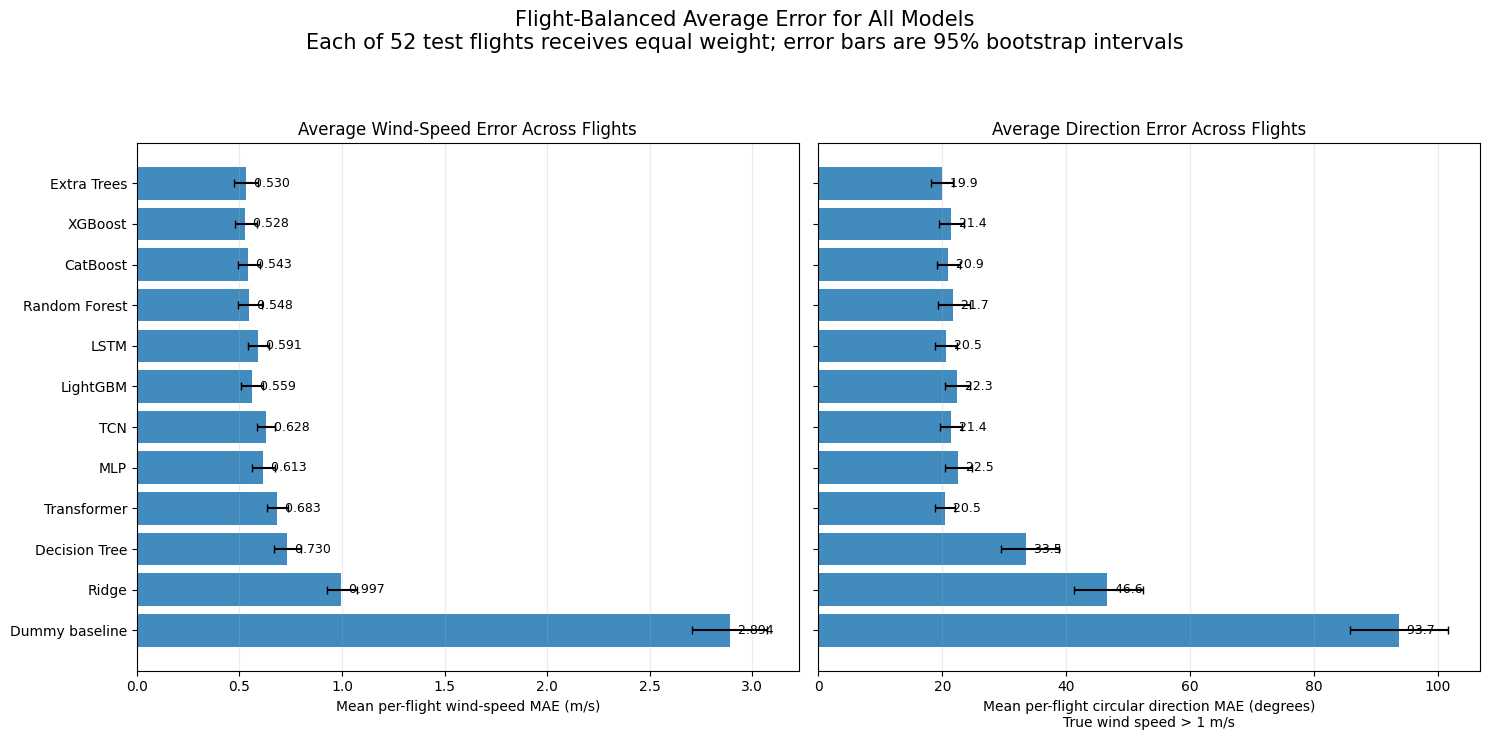

,display_name,n_flights,mean_per_flight_speed_mae_mps,speed_ci_low,speed_ci_high,mean_per_flight_direction_mae_deg,direction_ci_low,direction_ci_high,balanced_relative_score
0,Extra Trees,52,0.5296,0.4756,0.5917,19.92,18.15,21.75,1.0018
1,XGBoost,52,0.5277,0.4757,0.5841,21.42,19.48,23.53,1.0371
2,CatBoost,52,0.5431,0.4927,0.5996,20.94,19.14,22.88,1.0403
3,Random Forest,52,0.5477,0.4916,0.6117,21.73,19.32,24.48,1.0641
4,LSTM,52,0.5908,0.5401,0.6462,20.55,18.83,22.34,1.0748
5,LightGBM,52,0.5587,0.5073,0.6132,22.30,20.36,24.42,1.0887
6,TCN,52,0.6276,0.5851,0.6740,21.36,19.68,23.11,1.1294
7,MLP,52,0.6127,0.5592,0.6733,22.50,20.47,24.76,1.1454
8,Transformer,52,0.6833,0.6338,0.7389,20.46,18.84,22.11,1.1533
9,Decision Tree,52,0.7304,0.6670,0.8005,33.50,29.51,38.78,1.5258


In [18]:
# Average wind-speed and direction errors across all flights and all models.
# Run the earlier notebook cells that create `models` and `frames` first.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# ----------------------------
# Settings
# ----------------------------
DIRECTION_THRESHOLD = globals().get("DIRECTION_MIN_SPEED", 1.0)
N_BOOTSTRAP = 5000
CONFIDENCE_LEVEL = 0.95
RANDOM_SEED = 42
SORT_BY = "balanced"   # choices: "balanced", "speed", "direction", "name"
SAVE_OUTPUTS = True

if "models" not in globals() or "frames" not in globals():
    raise RuntimeError(
        "Run the notebook setup and model-loading cells first so `models` and `frames` exist."
    )


def calculate_per_flight_errors(
    frame: pd.DataFrame,
    direction_threshold: float,
) -> pd.DataFrame:
    """Calculate one speed MAE and one direction MAE for each flight."""
    speed = (
        frame.groupby("group_id", observed=True)
        .agg(
            n_rows=("row_key", "size"),
            speed_mae_mps=("abs_speed_error", "mean"),
        )
    )

    direction = (
        frame.loc[frame["true_speed"] > direction_threshold]
        .groupby("group_id", observed=True)
        .agg(
            direction_n=("row_key", "size"),
            direction_mae_deg=("abs_direction_error", "mean"),
        )
    )

    return speed.join(direction, how="left").reset_index()


def bootstrap_mean_interval(
    values: np.ndarray,
    *,
    n_bootstrap: int,
    confidence_level: float,
    random_seed: int,
) -> tuple[float, float, float]:
    """Return the mean and a bootstrap confidence interval across flights."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    mean_value = float(values.mean())

    if len(values) == 1:
        return mean_value, mean_value, mean_value

    rng = np.random.default_rng(random_seed)
    sampled_indices = rng.integers(
        0,
        len(values),
        size=(n_bootstrap, len(values)),
    )
    bootstrap_means = values[sampled_indices].mean(axis=1)

    alpha = 1.0 - confidence_level
    lower = float(np.quantile(bootstrap_means, alpha / 2.0))
    upper = float(np.quantile(bootstrap_means, 1.0 - alpha / 2.0))
    return mean_value, lower, upper


# Compute flight-level errors for every model.
per_flight_by_model = {
    model_name: calculate_per_flight_errors(
        frames[model_name],
        DIRECTION_THRESHOLD,
    )
    for model_name in sorted(models)
}

# Restrict all models to the same flights so the comparison is fair.
common_flights = None
for table in per_flight_by_model.values():
    valid_flights = set(
        table.loc[
            table["speed_mae_mps"].notna()
            & table["direction_mae_deg"].notna(),
            "group_id",
        ].astype(str)
    )
    common_flights = (
        valid_flights
        if common_flights is None
        else common_flights.intersection(valid_flights)
    )

common_flights = sorted(common_flights or [])

if len(common_flights) == 0:
    raise RuntimeError(
        "No flights have valid speed and direction errors for every model."
    )

# Calculate equal-flight-weighted averages and confidence intervals.
summary_rows = []

for index, model_name in enumerate(sorted(models)):
    table = per_flight_by_model[model_name].copy()
    table["group_id"] = table["group_id"].astype(str)
    table = (
        table.set_index("group_id")
        .loc[common_flights]
        .reset_index()
    )

    speed_mean, speed_low, speed_high = bootstrap_mean_interval(
        table["speed_mae_mps"].to_numpy(),
        n_bootstrap=N_BOOTSTRAP,
        confidence_level=CONFIDENCE_LEVEL,
        random_seed=RANDOM_SEED + 2 * index,
    )

    direction_mean, direction_low, direction_high = bootstrap_mean_interval(
        table["direction_mae_deg"].to_numpy(),
        n_bootstrap=N_BOOTSTRAP,
        confidence_level=CONFIDENCE_LEVEL,
        random_seed=RANDOM_SEED + 2 * index + 1,
    )

    summary_rows.append({
        "model": model_name,
        "display_name": models[model_name].display_name,
        "n_flights": len(table),
        "mean_per_flight_speed_mae_mps": speed_mean,
        "speed_ci_low": speed_low,
        "speed_ci_high": speed_high,
        "mean_per_flight_direction_mae_deg": direction_mean,
        "direction_ci_low": direction_low,
        "direction_ci_high": direction_high,
    })

average_errors = pd.DataFrame(summary_rows)

# Balanced score is used only for optional ordering.
best_speed = average_errors["mean_per_flight_speed_mae_mps"].min()
best_direction = average_errors["mean_per_flight_direction_mae_deg"].min()

average_errors["balanced_relative_score"] = np.sqrt(
    (
        average_errors["mean_per_flight_speed_mae_mps"]
        / best_speed
    )
    * (
        average_errors["mean_per_flight_direction_mae_deg"]
        / best_direction
    )
)

if SORT_BY == "speed":
    average_errors = average_errors.sort_values(
        ["mean_per_flight_speed_mae_mps", "display_name"]
    )
elif SORT_BY == "direction":
    average_errors = average_errors.sort_values(
        ["mean_per_flight_direction_mae_deg", "display_name"]
    )
elif SORT_BY == "name":
    average_errors = average_errors.sort_values("display_name")
elif SORT_BY == "balanced":
    average_errors = average_errors.sort_values(
        ["balanced_relative_score", "display_name"]
    )
else:
    raise ValueError(
        "SORT_BY must be 'balanced', 'speed', 'direction', or 'name'."
    )

average_errors = average_errors.reset_index(drop=True)

# ----------------------------
# Plot
# ----------------------------
labels = average_errors["display_name"].to_numpy()
positions = np.arange(len(average_errors))

speed_values = average_errors["mean_per_flight_speed_mae_mps"].to_numpy()
speed_xerr = np.vstack([
    speed_values - average_errors["speed_ci_low"].to_numpy(),
    average_errors["speed_ci_high"].to_numpy() - speed_values,
])

direction_values = average_errors["mean_per_flight_direction_mae_deg"].to_numpy()
direction_xerr = np.vstack([
    direction_values - average_errors["direction_ci_low"].to_numpy(),
    average_errors["direction_ci_high"].to_numpy() - direction_values,
])

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 7.5),
    sharey=True,
)

axes[0].barh(
    positions,
    speed_values,
    xerr=speed_xerr,
    capsize=3,
    alpha=0.85,
)
axes[0].set_yticks(positions, labels)
axes[0].invert_yaxis()
axes[0].set_xlabel("Mean per-flight wind-speed MAE (m/s)")
axes[0].set_title("Average Wind-Speed Error Across Flights")
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(
    positions,
    direction_values,
    xerr=direction_xerr,
    capsize=3,
    alpha=0.85,
)
axes[1].set_xlabel(
    f"Mean per-flight circular direction MAE (degrees)\n"
    f"True wind speed > {DIRECTION_THRESHOLD:g} m/s"
)
axes[1].set_title("Average Direction Error Across Flights")
axes[1].grid(axis="x", alpha=0.25)

for index, value in enumerate(speed_values):
    axes[0].text(
        value,
        index,
        f"  {value:.3f}",
        va="center",
        fontsize=9,
    )

for index, value in enumerate(direction_values):
    axes[1].text(
        value,
        index,
        f"  {value:.1f}",
        va="center",
        fontsize=9,
    )

fig.suptitle(
    "Flight-Balanced Average Error for All Models\n"
    f"Each of {len(common_flights)} test flights receives equal weight; "
    f"error bars are {int(CONFIDENCE_LEVEL * 100)}% bootstrap intervals",
    fontsize=15,
)

plt.tight_layout(rect=(0, 0, 1, 0.93))

# ----------------------------
# Save outputs
# ----------------------------
if SAVE_OUTPUTS:
    output_dir = (
        Path(OUTPUT_DIR)
        if "OUTPUT_DIR" in globals()
        else Path("results") / "scc" / "final_analysis"
    )
    figures_dir = output_dir / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    png_path = figures_dir / "12_average_errors_all_flights_all_models.png"
    pdf_path = figures_dir / "12_average_errors_all_flights_all_models.pdf"
    csv_path = output_dir / "average_errors_all_flights_all_models.csv"

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    average_errors.to_csv(csv_path, index=False)

    print(f"Saved PNG: {png_path}")
    print(f"Saved PDF: {pdf_path}")
    print(f"Saved table: {csv_path}")

plt.show()

# Display the numerical results.
display(
    average_errors[
        [
            "display_name",
            "n_flights",
            "mean_per_flight_speed_mae_mps",
            "speed_ci_low",
            "speed_ci_high",
            "mean_per_flight_direction_mae_deg",
            "direction_ci_low",
            "direction_ci_high",
            "balanced_relative_score",
        ]
    ].style.format({
        "n_flights": "{:,.0f}",
        "mean_per_flight_speed_mae_mps": "{:.4f}",
        "speed_ci_low": "{:.4f}",
        "speed_ci_high": "{:.4f}",
        "mean_per_flight_direction_mae_deg": "{:.2f}",
        "direction_ci_low": "{:.2f}",
        "direction_ci_high": "{:.2f}",
        "balanced_relative_score": "{:.4f}",
    })
)

Device:       cpu
MC passes:    30
Data:         C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\data\full_standardized.csv
Test split:   C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\data\full_split_manifest.csv
Model root:   C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\scc\baseline
Output:       C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\scc\final_analysis\internal_test_confidence\mc_dropout
Internal test rows: 67,027; flights: 53
Neural models: ['1_mlp', '2_lstm', '3_tcn', '4_transformer']

Evaluating 1_mlp...
  speed MAE=0.610 m/s; direction MAE=30.23°; mean speed uncertainty=0.422 m/s

Evaluating 2_lstm...
  speed MAE=0.594 m/s; direction MAE=27.40°; mean speed uncertainty=0.277 m/s

Evaluating 3_tcn...
  speed MAE=0.634 m/s; direction MAE=28.83°; mean speed uncertainty=0.393 m/s

Evaluating 4_transformer...


C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\src\neural_models.py:284: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=max(1, args.num_layers))


  speed MAE=0.679 m/s; direction MAE=27.24°; mean speed uncertainty=0.000 m/s


,model,mc_passes,rows_evaluated,flights_evaluated,speed_mae_mps,speed_rmse_mps,direction_circular_mae_deg,direction_within_30deg_fraction,direction_speed_ge_1_mps_mae_deg,mean_speed_uncertainty_std_mps,median_speed_uncertainty_std_mps,speed_95pct_interval_coverage,mean_direction_uncertainty_std_deg,median_direction_uncertainty_std_deg,speed_uncertainty_error_correlation,direction_uncertainty_error_correlation
0,lstm,30,65490,53,0.5937,0.8090,27.4044,0.7303,20.8432,0.2768,0.2503,0.5571,3.9983,3.6261,0.0750,0.1576
1,mlp,30,67027,53,0.6104,0.8397,30.2319,0.7013,23.4380,0.4224,0.3595,0.7105,11.1860,7.9365,0.1601,0.4643
2,tcn,30,65490,53,0.6344,0.8368,28.8290,0.7166,21.9364,0.3934,0.3338,0.6587,6.3393,5.3719,0.1536,0.2791
3,transformer,30,65490,53,0.6794,0.8946,27.2355,0.7254,21.0083,0.0000,0.0000,0.0000,0.0167,0.0000,0.1014,-0.0100


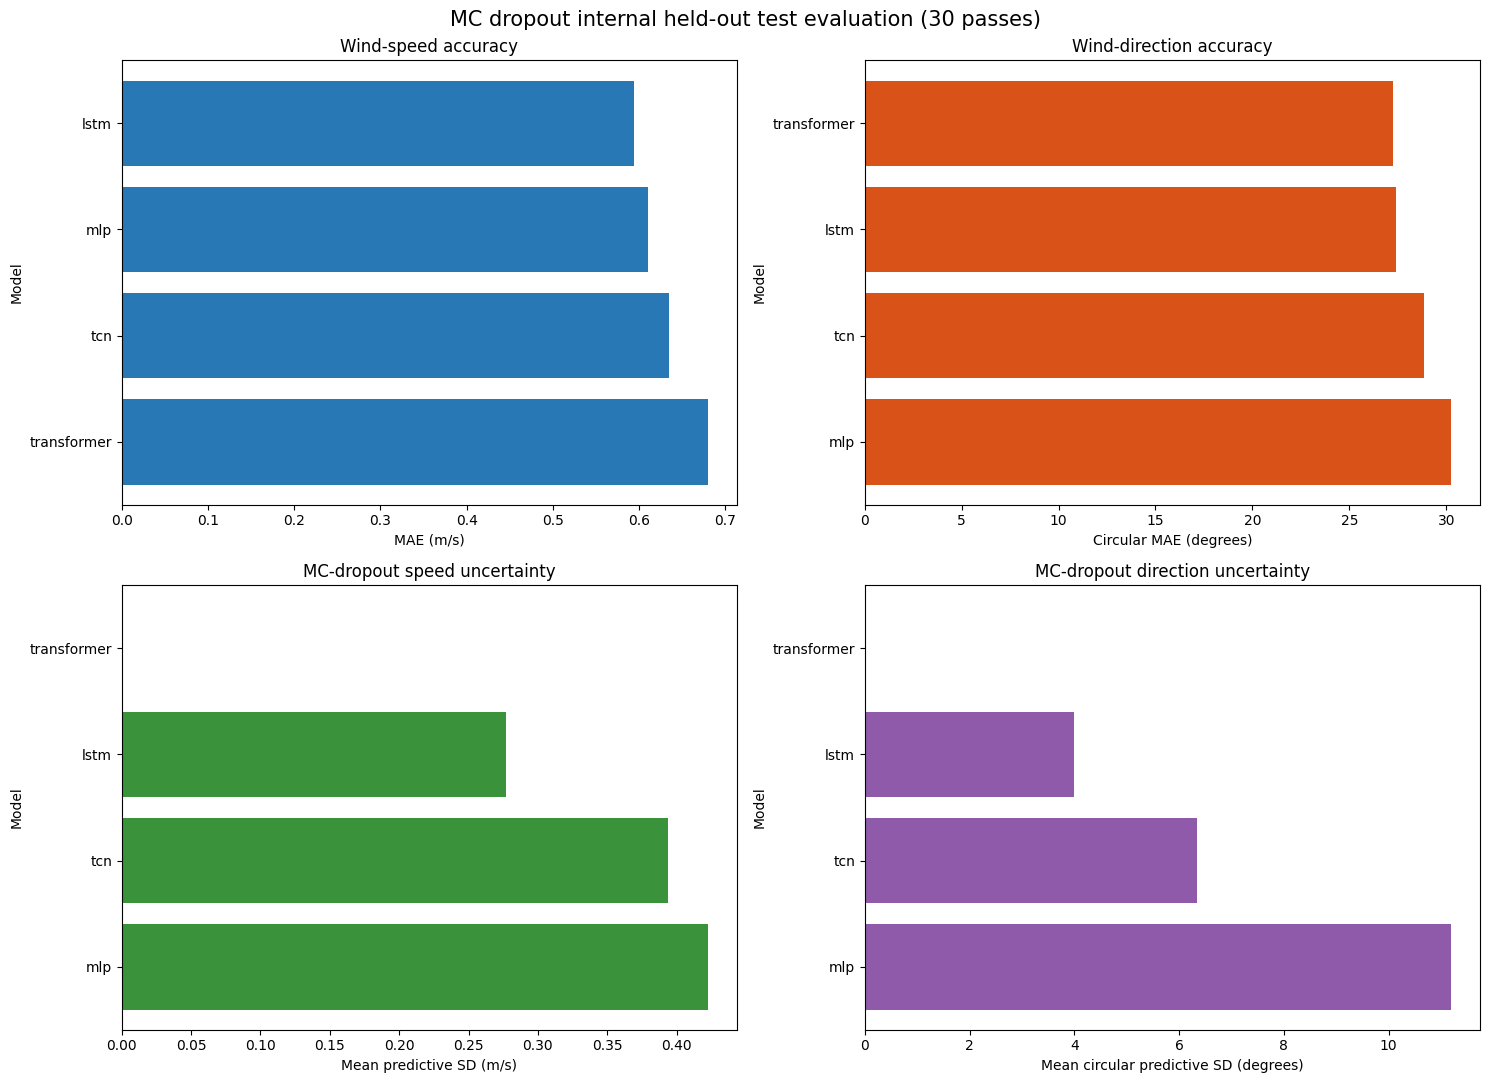

Saved figure: C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\scc\final_analysis\internal_test_confidence\mc_dropout\mc_dropout_accuracy_and_uncertainty.png


In [19]:
# ============================================================
# MONTE CARLO DROPOUT EVALUATION — NO RETRAINING
# ============================================================

from pathlib import Path
from types import SimpleNamespace
import math

import numpy as np
import pandas as pd
import torch
from torch import nn

from src.neural_models import build_network
from src.wind_core import (
    add_engineered_features,
    circular_difference_deg,
    load_split,
    load_standardized_data,
    modeled_to_absolute_angle,
    yaw_to_heading_deg,
)

# Explicitly evaluate the original frozen internal test split.
PROJECT_ROOT = Path(globals().get("PROJECT_ROOT", Path.cwd())).resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MC_DATA_FILE = PROJECT_ROOT / "data" / "full_standardized.csv"
MC_SPLIT_MANIFEST = PROJECT_ROOT / "data" / "full_split_manifest.csv"
MC_MODEL_ROOT = Path(
    globals().get(
        "MODEL_ROOT",
        PROJECT_ROOT / "results" / "scc" / "baseline",
    )
)
MC_OUTPUT_DIR = (
    PROJECT_ROOT / "results" / "scc" / "final_analysis"
    / "internal_test_confidence" / "mc_dropout"
)

MC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MC_PASSES = 30          # Increase to 50–100 for final uncertainty estimates.
MC_BATCH_SIZE = 2048
MC_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_ROW_RESULTS = True  # Set False if disk space is limited.

print(f"Device:       {MC_DEVICE}")
print(f"MC passes:    {MC_PASSES}")
print(f"Data:         {MC_DATA_FILE}")
print(f"Test split:   {MC_SPLIT_MANIFEST}")
print(f"Model root:   {MC_MODEL_ROOT}")
print(f"Output:       {MC_OUTPUT_DIR}")


def enable_mc_dropout(model):
    """Use inference mode while keeping dropout layers stochastic."""
    model.eval()
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()


def prepare_checkpoint_input(checkpoint, engineered):
    """Apply the preprocessing saved with the trained model."""
    features = checkpoint["feature_columns"]
    missing = sorted(set(features) - set(engineered.columns))
    if missing:
        raise ValueError(f"Missing model features: {missing}")

    raw = engineered[features].to_numpy(dtype=float)
    state = checkpoint["preprocessor"]

    imputer_statistics = np.asarray(
        state["imputer_statistics"], dtype=float
    )
    scaler_mean = np.asarray(state["scaler_mean"], dtype=float)
    scaler_scale = np.asarray(state["scaler_scale"], dtype=float)

    raw = np.where(np.isfinite(raw), raw, np.nan)
    raw = np.where(np.isnan(raw), imputer_statistics[None, :], raw)

    scaler_scale = np.where(scaler_scale == 0, 1.0, scaler_scale)
    matrix = (raw - scaler_mean) / scaler_scale

    return matrix.astype(np.float32), features


def get_endpoints(engineered, model_name, sequence_length):
    endpoints = []

    for _, flight in engineered.groupby(
        "_Group_ID", sort=False, observed=True
    ):
        indices = flight.index.to_numpy(dtype=np.int64)

        if model_name == "mlp":
            endpoints.extend(indices)
        elif len(indices) >= sequence_length:
            endpoints.extend(indices[sequence_length - 1:])

    return np.asarray(endpoints, dtype=np.int64)


def make_batch(matrix, endpoints, model_name, sequence_length):
    if model_name == "mlp":
        return matrix[endpoints]

    return np.stack(
        [
            matrix[
                endpoint - sequence_length + 1:
                endpoint + 1
            ]
            for endpoint in endpoints
        ]
    )


def evaluate_mc_dropout_model(
    artifact_path,
    engineered,
    mc_passes=30,
    batch_size=2048,
):
    checkpoint = torch.load(
        artifact_path,
        map_location=MC_DEVICE,
        weights_only=False,
    )

    model_name = checkpoint["model_name"]
    config = checkpoint["model_config"]
    args = SimpleNamespace(**config)

    matrix, features = prepare_checkpoint_input(
        checkpoint, engineered
    )

    model = build_network(
        model_name,
        len(features),
        args,
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(MC_DEVICE)
    enable_mc_dropout(model)

    sequence_length = (
        1
        if model_name == "mlp"
        else int(config["sequence_length"])
    )

    endpoints = get_endpoints(
        engineered,
        model_name,
        sequence_length,
    )

    target_scaling = checkpoint["target_scaling"]
    speed_mean = float(target_scaling["speed_mean"])
    speed_std = float(target_scaling["speed_std"])

    mean_speed_parts = []
    speed_std_parts = []
    mean_modeled_angle_parts = []
    circular_std_parts = []

    with torch.inference_mode():
        for start in range(0, len(endpoints), batch_size):
            batch_endpoints = endpoints[start:start + batch_size]

            batch = make_batch(
                matrix,
                batch_endpoints,
                model_name,
                sequence_length,
            )
            batch_tensor = torch.from_numpy(batch).to(MC_DEVICE)

            speed_samples = []
            angle_samples_rad = []

            for _ in range(mc_passes):
                output = model(batch_tensor)

                predicted_speed = (
                    output[:, 0] * speed_std + speed_mean
                ).clamp_min(0.0)

                direction_vector = output[:, 1:3]
                modeled_angle = torch.atan2(
                    direction_vector[:, 0],
                    direction_vector[:, 1],
                )

                speed_samples.append(
                    predicted_speed.detach().cpu().numpy()
                )
                angle_samples_rad.append(
                    modeled_angle.detach().cpu().numpy()
                )

            speed_samples = np.stack(speed_samples, axis=0)
            angle_samples_rad = np.stack(angle_samples_rad, axis=0)

            mean_speed_parts.append(speed_samples.mean(axis=0))
            speed_std_parts.append(
                speed_samples.std(axis=0, ddof=1)
            )

            mean_sin = np.sin(angle_samples_rad).mean(axis=0)
            mean_cos = np.cos(angle_samples_rad).mean(axis=0)

            mean_modeled_angle = (
                np.rad2deg(np.arctan2(mean_sin, mean_cos)) + 360.0
            ) % 360.0

            # Circular predictive uncertainty:
            # 0 degrees means agreement; larger means more uncertainty.
            resultant_length = np.sqrt(mean_sin**2 + mean_cos**2)
            resultant_length = np.clip(
                resultant_length, 1e-12, 1.0
            )
            circular_std_deg = np.rad2deg(
                np.sqrt(-2.0 * np.log(resultant_length))
            )

            mean_modeled_angle_parts.append(mean_modeled_angle)
            circular_std_parts.append(circular_std_deg)

    predicted_speed = np.concatenate(mean_speed_parts)
    predicted_speed_std = np.concatenate(speed_std_parts)
    predicted_modeled_angle = np.concatenate(
        mean_modeled_angle_parts
    )
    predicted_direction_std = np.concatenate(circular_std_parts)

    target_mode = config.get(
        "direction_target_mode", "absolute"
    )

    if target_mode == "relative_yaw":
        yaw_transform = config.get(
            "yaw_transform", "clockwise_from_north"
        )
        yaw_heading = yaw_to_heading_deg(
            engineered.iloc[endpoints]["Yaw"].to_numpy(),
            "radians",
            yaw_transform,
        )
        predicted_angle = modeled_to_absolute_angle(
            predicted_modeled_angle,
            target_mode,
            yaw_heading,
        )
    else:
        predicted_angle = predicted_modeled_angle

    result = engineered.iloc[endpoints][
        [
            "_Group_ID",
            "Flight_ID",
            "Wind_speed",
            "Wind_angle",
        ]
    ].copy()

    result["model"] = model_name
    result["Predicted_wind_speed"] = predicted_speed
    result["Speed_uncertainty_std_mps"] = predicted_speed_std
    result["Predicted_wind_angle"] = predicted_angle
    result["Direction_uncertainty_std_deg"] = (
        predicted_direction_std
    )

    result["Speed_error_mps"] = (
        result["Predicted_wind_speed"] - result["Wind_speed"]
    )
    result["Speed_absolute_error_mps"] = (
        result["Speed_error_mps"].abs()
    )

    result["Direction_error_deg"] = circular_difference_deg(
        result["Wind_angle"].to_numpy(),
        result["Predicted_wind_angle"].to_numpy(),
    )
    result["Direction_absolute_error_deg"] = (
        result["Direction_error_deg"].abs()
    )

    # Approximate 95% MC-dropout interval for wind speed.
    lower = (
        result["Predicted_wind_speed"]
        - 1.96 * result["Speed_uncertainty_std_mps"]
    )
    upper = (
        result["Predicted_wind_speed"]
        + 1.96 * result["Speed_uncertainty_std_mps"]
    )
    result["Speed_inside_95pct_interval"] = (
        (result["Wind_speed"] >= lower)
        & (result["Wind_speed"] <= upper)
    )

    reliable = result["Wind_speed"] >= 1.0
    speed_error = result["Speed_error_mps"].to_numpy()
    direction_error = result["Direction_error_deg"].to_numpy()

    metrics = {
        "model": model_name,
        "mc_passes": mc_passes,
        "rows_evaluated": len(result),
        "flights_evaluated": result["Flight_ID"].nunique(),

        # Overall predictive accuracy
        "speed_mae_mps": float(
            np.mean(np.abs(speed_error))
        ),
        "speed_rmse_mps": float(
            np.sqrt(np.mean(speed_error**2))
        ),
        "direction_circular_mae_deg": float(
            np.mean(np.abs(direction_error))
        ),
        "direction_within_30deg_fraction": float(
            np.mean(np.abs(direction_error) <= 30.0)
        ),
        "direction_speed_ge_1_mps_mae_deg": float(
            np.mean(np.abs(direction_error[reliable]))
        ),

        # Overall uncertainty
        "mean_speed_uncertainty_std_mps": float(
            result["Speed_uncertainty_std_mps"].mean()
        ),
        "median_speed_uncertainty_std_mps": float(
            result["Speed_uncertainty_std_mps"].median()
        ),
        "speed_95pct_interval_coverage": float(
            result["Speed_inside_95pct_interval"].mean()
        ),
        "mean_direction_uncertainty_std_deg": float(
            result["Direction_uncertainty_std_deg"].mean()
        ),
        "median_direction_uncertainty_std_deg": float(
            result["Direction_uncertainty_std_deg"].median()
        ),

        # Does uncertainty increase when error increases?
        "speed_uncertainty_error_correlation": float(
            result[
                [
                    "Speed_uncertainty_std_mps",
                    "Speed_absolute_error_mps",
                ]
            ].corr().iloc[0, 1]
        ),
        "direction_uncertainty_error_correlation": float(
            result[
                [
                    "Direction_uncertainty_std_deg",
                    "Direction_absolute_error_deg",
                ]
            ].corr().iloc[0, 1]
        ),
    }

    return metrics, result


# ------------------------------------------------------------
# Load and engineer the original data, then retain held-out test flights
# ------------------------------------------------------------

mc_data = load_standardized_data(MC_DATA_FILE)
mc_engineered, _, mc_metadata = add_engineered_features(
    mc_data,
    attitude_angle_unit="radians",
)
_, mc_test_indices, _ = load_split(
    mc_engineered,
    MC_SPLIT_MANIFEST,
)
mc_engineered = (
    mc_engineered.iloc[mc_test_indices]
    .copy()
    .reset_index(drop=True)
)
print(
    f"Internal test rows: {len(mc_engineered):,}; "
    f"flights: {mc_engineered['_Group_ID'].nunique():,}"
)

neural_artifacts = sorted(
    (MC_MODEL_ROOT / "gpu").glob("*/wind_model.pt")
)

if not neural_artifacts:
    raise FileNotFoundError(
        f"No neural model checkpoints found below {MC_MODEL_ROOT / 'gpu'}"
    )

print(
    "Neural models:",
    [path.parent.name for path in neural_artifacts],
)

# ------------------------------------------------------------
# Run MC dropout
# ------------------------------------------------------------

mc_metrics = []
mc_failures = []
mc_results_by_model = {}

for artifact_path in neural_artifacts:
    print(f"\nEvaluating {artifact_path.parent.name}...")

    try:
        metrics, result = evaluate_mc_dropout_model(
            artifact_path,
            mc_engineered,
            mc_passes=MC_PASSES,
            batch_size=MC_BATCH_SIZE,
        )

        mc_metrics.append(metrics)
        mc_results_by_model[metrics["model"]] = result

        if SAVE_ROW_RESULTS:
            result.to_csv(
                MC_OUTPUT_DIR
                / f"{metrics['model']}_mc_dropout_predictions.csv",
                index=False,
            )

        print(
            f"  speed MAE={metrics['speed_mae_mps']:.3f} m/s; "
            f"direction MAE="
            f"{metrics['direction_circular_mae_deg']:.2f}°; "
            f"mean speed uncertainty="
            f"{metrics['mean_speed_uncertainty_std_mps']:.3f} m/s"
        )

    except Exception as error:
        mc_failures.append(
            {
                "artifact": str(artifact_path),
                "error": f"{type(error).__name__}: {error}",
            }
        )
        print(f"  FAILED: {type(error).__name__}: {error}")

mc_summary = pd.DataFrame(mc_metrics).sort_values(
    ["speed_mae_mps", "direction_circular_mae_deg"],
    ignore_index=True,
)
mc_failure_table = pd.DataFrame(
    mc_failures,
    columns=["artifact", "error"],
)

mc_summary.to_csv(
    MC_OUTPUT_DIR / "mc_dropout_overall_metrics.csv",
    index=False,
)
mc_failure_table.to_csv(
    MC_OUTPUT_DIR / "mc_dropout_failures.csv",
    index=False,
)

display(mc_summary)

if not mc_failure_table.empty:
    display(mc_failure_table)

# ------------------------------------------------------------
# Accuracy and uncertainty figure
# ------------------------------------------------------------

if not mc_summary.empty:
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))

    plots = [
        (
            "speed_mae_mps",
            "Wind-speed accuracy",
            "MAE (m/s)",
            "#2878B5",
        ),
        (
            "direction_circular_mae_deg",
            "Wind-direction accuracy",
            "Circular MAE (degrees)",
            "#D95319",
        ),
        (
            "mean_speed_uncertainty_std_mps",
            "MC-dropout speed uncertainty",
            "Mean predictive SD (m/s)",
            "#3A923A",
        ),
        (
            "mean_direction_uncertainty_std_deg",
            "MC-dropout direction uncertainty",
            "Mean circular predictive SD (degrees)",
            "#8E5AA9",
        ),
    ]

    for ax, (column, title, label, color) in zip(
        axes.flat, plots
    ):
        ordered = mc_summary.sort_values(column)
        ax.barh(ordered["model"], ordered[column], color=color)
        ax.invert_yaxis()
        ax.set_title(title)
        ax.set_xlabel(label)
        ax.set_ylabel("Model")

    fig.suptitle(
        f"MC dropout internal held-out test evaluation ({MC_PASSES} passes)",
        fontsize=15,
    )
    fig.tight_layout()

    figure_path = (
        MC_OUTPUT_DIR / "mc_dropout_accuracy_and_uncertainty.png"
    )
    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved figure: {figure_path}")

Data:       C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\data\full_standardized.csv
Test split: C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\data\full_split_manifest.csv
Models:     C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\scc\baseline
Output:     C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\scc\final_analysis\internal_test_confidence\tabular_confidence
Internal test rows: 67,027; flights: 53
Tabular artifacts: ['1_extra_trees', '2_random_forest', '3_decision_tree', '4_ridge', '5_dummy', '6_xgboost', '7_lightgbm', '8_catboost']

Evaluating 1_extra_trees...
  speed MAE=0.525 m/s; direction MAE=28.66°; mean direction confidence=0.725

Evaluating 2_random_forest...
  speed MAE=0.539 m/s; direction MAE=30.13°; mean direction confidence=0.738

Evaluating 3_decision_tree...
  speed MAE=0.725 m/s; direction MAE=40.92°; mean direction c

,model,model_family,rows_evaluated,flights_evaluated,speed_mae_mps,speed_rmse_mps,direction_circular_mae_deg,direction_within_30deg_fraction,direction_speed_ge_1_mps_mae_deg,mean_direction_confidence,median_direction_confidence,direction_confidence_ge_0p8_fraction,direction_confidence_below_0p5_fraction,high_confidence_direction_mae_deg,low_confidence_direction_mae_deg,direction_confidence_vs_error_spearman,speed_uncertainty_available,ensemble_tree_count,mean_speed_ensemble_std_mps,median_speed_ensemble_std_mps,speed_approx_95pct_interval_coverage,speed_uncertainty_vs_error_spearman
0,xgboost,xgboost,67027,53,0.5241,0.7483,29.4124,0.7093,23.0630,0.7656,0.8643,0.5640,0.1913,13.4641,60.0892,-0.5825,False,None,NaN,NaN,NaN,NaN
1,extra_trees,extra_trees,67027,53,0.5252,0.7486,28.6586,0.7159,21.5276,0.7250,0.7997,0.4996,0.2220,9.9626,62.5772,-0.6409,False,None,NaN,NaN,NaN,NaN
2,catboost,catboost,67027,53,0.5384,0.7555,28.5457,0.7183,22.3166,0.7734,0.8726,0.5808,0.1790,13.9202,62.3909,-0.5579,False,None,NaN,NaN,NaN,NaN
3,random_forest,random_forest,67027,53,0.5389,0.8001,30.1346,0.6969,23.2228,0.7381,0.8331,0.5340,0.2199,12.1269,62.6173,-0.6289,False,None,NaN,NaN,NaN,NaN
4,lightgbm,lightgbm,67027,53,0.5527,0.7711,30.2297,0.6965,23.8067,0.7509,0.8316,0.5325,0.1943,13.9420,61.7204,-0.5592,False,None,NaN,NaN,NaN,NaN
5,decision_tree,decision_tree,67027,53,0.7248,1.0656,40.9207,0.5971,34.9975,0.9271,0.9842,0.8042,0.0741,34.5874,78.2980,-0.1774,False,None,NaN,NaN,NaN,NaN
6,ridge,ridge,67027,53,0.9663,1.2696,51.0395,0.4508,47.0034,0.5069,0.4569,0.1422,0.5666,18.3857,62.7488,-0.3804,False,None,NaN,NaN,NaN,NaN
7,dummy,dummy,67027,53,2.8312,3.4857,90.5931,0.2184,91.8983,0.0686,0.0686,0.0000,1.0000,NaN,90.5931,NaN,False,None,NaN,NaN,NaN,NaN


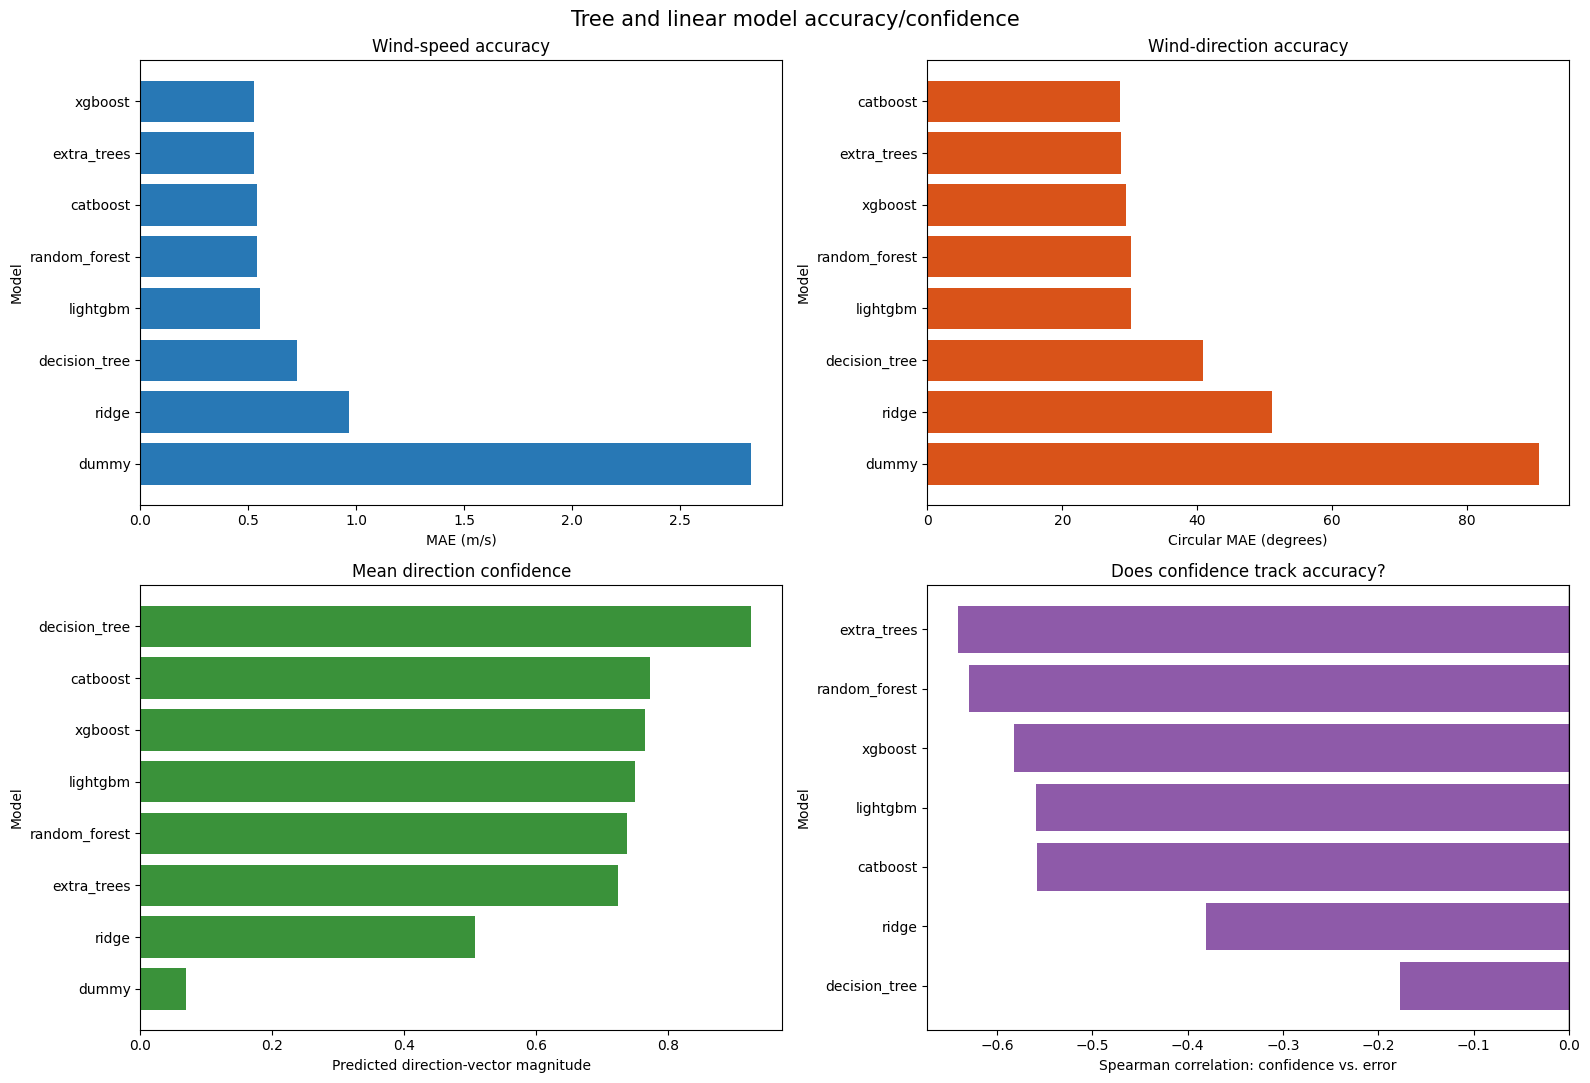

Saved figure: C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\scc\final_analysis\internal_test_confidence\tabular_confidence\tabular_accuracy_and_confidence.png
No supported Random Forest or Extra Trees ensemble uncertainty was found.


In [21]:
# ============================================================
# TREE / LINEAR MODEL ACCURACY AND CONFIDENCE EVALUATION
# ============================================================

from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.wind_core import (
    add_engineered_features,
    circular_difference_deg,
    load_split,
    load_standardized_data,
    modeled_to_absolute_angle,
    vectors_to_angle_and_confidence,
    yaw_to_heading_deg,
)

warnings.filterwarnings(
    "ignore",
    message=".*loading a serialized model.*older version of XGBoost.*",
)
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names.*",
)

PROJECT_ROOT = Path(
    globals().get("PROJECT_ROOT", Path.cwd())
).resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TABULAR_DATA_FILE = (
    PROJECT_ROOT / "data" / "full_standardized.csv"
)
TABULAR_SPLIT_MANIFEST = (
    PROJECT_ROOT / "data" / "full_split_manifest.csv"
)

TABULAR_MODEL_ROOT = Path(
    globals().get(
        "MODEL_ROOT",
        PROJECT_ROOT / "results" / "scc" / "baseline",
    )
)

TABULAR_OUTPUT_DIR = (
    PROJECT_ROOT / "results" / "scc" / "final_analysis"
    / "internal_test_confidence" / "tabular_confidence"
)

TABULAR_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Saving all row-level predictions can use substantial disk space.
SAVE_TABULAR_ROW_RESULTS = False

print(f"Data:       {TABULAR_DATA_FILE}")
print(f"Test split: {TABULAR_SPLIT_MANIFEST}")
print(f"Models:     {TABULAR_MODEL_ROOT}")
print(f"Output:     {TABULAR_OUTPUT_DIR}")


def convert_to_absolute_direction(
    modeled_angle,
    artifact,
    engineered,
):
    """Convert relative-yaw outputs when a model uses that target."""
    arguments = artifact.get("training_arguments", {})
    target_mode = arguments.get(
        "direction_target", "absolute"
    )

    if target_mode == "absolute":
        return modeled_angle

    yaw_transform = arguments.get(
        "yaw_transform", "clockwise_from_north"
    )

    yaw_heading = yaw_to_heading_deg(
        engineered["Yaw"].to_numpy(),
        "radians",
        yaw_transform,
    )

    return modeled_to_absolute_angle(
        modeled_angle,
        target_mode,
        yaw_heading,
    )


def unwrap_fitted_estimator(estimator):
    """Unwrap project sample-weight wrappers when present."""
    visited = set()

    while hasattr(estimator, "estimator_"):
        if id(estimator) in visited:
            break

        visited.add(id(estimator))
        estimator = estimator.estimator_

    return estimator


def forest_speed_uncertainty(speed_pipeline, X):
    """
    Return standard deviation across individual trees.

    This is available for fitted RandomForest and ExtraTrees models.
    It is not a calibrated prediction interval.
    """
    if not hasattr(speed_pipeline, "steps"):
        return None, None

    preprocessing = speed_pipeline[:-1]
    final_step = speed_pipeline.steps[-1][1]
    estimator = unwrap_fitted_estimator(final_step)

    class_name = type(estimator).__name__.lower()

    is_supported_forest = (
        "randomforest" in class_name
        or "extratrees" in class_name
    )

    if not is_supported_forest:
        return None, None

    if not hasattr(estimator, "estimators_"):
        return None, None

    transformed = preprocessing.transform(X)

    tree_predictions = np.vstack(
        [
            np.asarray(
                tree.predict(transformed),
                dtype=float,
            )
            for tree in estimator.estimators_
        ]
    )

    ensemble_std = tree_predictions.std(axis=0, ddof=1)

    return ensemble_std, len(estimator.estimators_)


def evaluate_tabular_confidence(
    artifact_path,
    engineered,
):
    artifact = joblib.load(
        artifact_path,
        mmap_mode="r",
    )

    model_name = artifact.get(
        "model_name",
        artifact_path.parent.name,
    )

    feature_columns = artifact["feature_columns"]
    missing = sorted(
        set(feature_columns) - set(engineered.columns)
    )

    if missing:
        raise ValueError(
            f"{model_name} is missing features: {missing}"
        )

    X = engineered[feature_columns]

    speed_model = artifact["speed_model"]
    direction_model = artifact["direction_model"]

    predicted_speed = np.maximum(
        np.asarray(
            speed_model.predict(X),
            dtype=float,
        ),
        0.0,
    )

    predicted_vectors = np.asarray(
        direction_model.predict(X),
        dtype=float,
    )

    modeled_angle, direction_confidence = (
        vectors_to_angle_and_confidence(
            predicted_vectors
        )
    )

    predicted_angle = convert_to_absolute_direction(
        modeled_angle,
        artifact,
        engineered,
    )

    speed_uncertainty, tree_count = (
        forest_speed_uncertainty(
            speed_model,
            X,
        )
    )

    result = engineered[
        [
            "_Group_ID",
            "Flight_ID",
            "Wind_speed",
            "Wind_angle",
        ]
    ].copy()

    result["model"] = model_name
    result["Predicted_wind_speed"] = predicted_speed
    result["Predicted_wind_angle"] = predicted_angle

    # Magnitude of the predicted [sin, cos] vector.
    # Values near 1 generally indicate a decisive direction output.
    result["Direction_confidence"] = (
        direction_confidence
    )

    result["Speed_error_mps"] = (
        result["Predicted_wind_speed"]
        - result["Wind_speed"]
    )
    result["Speed_absolute_error_mps"] = (
        result["Speed_error_mps"].abs()
    )

    result["Direction_error_deg"] = (
        circular_difference_deg(
            result["Wind_angle"].to_numpy(),
            result[
                "Predicted_wind_angle"
            ].to_numpy(),
        )
    )
    result["Direction_absolute_error_deg"] = (
        result["Direction_error_deg"].abs()
    )

    if speed_uncertainty is not None:
        result["Speed_ensemble_std_mps"] = (
            speed_uncertainty
        )

        lower = (
            result["Predicted_wind_speed"]
            - 1.96
            * result["Speed_ensemble_std_mps"]
        )
        upper = (
            result["Predicted_wind_speed"]
            + 1.96
            * result["Speed_ensemble_std_mps"]
        )

        result["Speed_inside_approx_95pct_interval"] = (
            (result["Wind_speed"] >= lower)
            & (result["Wind_speed"] <= upper)
        )
    else:
        result["Speed_ensemble_std_mps"] = np.nan
        result[
            "Speed_inside_approx_95pct_interval"
        ] = pd.NA

    speed_error = result[
        "Speed_error_mps"
    ].to_numpy(dtype=float)

    direction_error = result[
        "Direction_error_deg"
    ].to_numpy(dtype=float)

    reliable_direction = (
        result["Wind_speed"].to_numpy() >= 1.0
    )

    high_confidence = (
        result["Direction_confidence"] >= 0.8
    )
    low_confidence = (
        result["Direction_confidence"] < 0.5
    )

    metrics = {
        "model": model_name,
        "model_family": (
            artifact.get(
                "training_arguments", {}
            ).get("model", model_name)
        ),
        "rows_evaluated": len(result),
        "flights_evaluated": (
            result["Flight_ID"].nunique()
        ),

        # Overall accuracy
        "speed_mae_mps": float(
            np.mean(np.abs(speed_error))
        ),
        "speed_rmse_mps": float(
            np.sqrt(np.mean(speed_error**2))
        ),
        "direction_circular_mae_deg": float(
            np.mean(np.abs(direction_error))
        ),
        "direction_within_30deg_fraction": float(
            np.mean(
                np.abs(direction_error) <= 30.0
            )
        ),
        "direction_speed_ge_1_mps_mae_deg": (
            float(
                np.mean(
                    np.abs(
                        direction_error[
                            reliable_direction
                        ]
                    )
                )
            )
            if reliable_direction.any()
            else np.nan
        ),

        # Direction-confidence diagnostics
        "mean_direction_confidence": float(
            result["Direction_confidence"].mean()
        ),
        "median_direction_confidence": float(
            result["Direction_confidence"].median()
        ),
        "direction_confidence_ge_0p8_fraction": float(
            high_confidence.mean()
        ),
        "direction_confidence_below_0p5_fraction": float(
            low_confidence.mean()
        ),
        "high_confidence_direction_mae_deg": (
            float(
                result.loc[
                    high_confidence,
                    "Direction_absolute_error_deg",
                ].mean()
            )
            if high_confidence.any()
            else np.nan
        ),
        "low_confidence_direction_mae_deg": (
            float(
                result.loc[
                    low_confidence,
                    "Direction_absolute_error_deg",
                ].mean()
            )
            if low_confidence.any()
            else np.nan
        ),

        # A negative value is desirable:
        # confidence increases as absolute error decreases.
        "direction_confidence_vs_error_spearman": (
            float(
                result[
                    [
                        "Direction_confidence",
                        "Direction_absolute_error_deg",
                    ]
                ]
                .corr(method="spearman")
                .iloc[0, 1]
            )
        ),

        # Forest-only uncertainty
        "speed_uncertainty_available": (
            speed_uncertainty is not None
        ),
        "ensemble_tree_count": tree_count,
        "mean_speed_ensemble_std_mps": (
            float(np.mean(speed_uncertainty))
            if speed_uncertainty is not None
            else np.nan
        ),
        "median_speed_ensemble_std_mps": (
            float(np.median(speed_uncertainty))
            if speed_uncertainty is not None
            else np.nan
        ),
        "speed_approx_95pct_interval_coverage": (
            float(
                result[
                    "Speed_inside_approx_95pct_interval"
                ]
                .astype(float)
                .mean()
            )
            if speed_uncertainty is not None
            else np.nan
        ),
        "speed_uncertainty_vs_error_spearman": (
            float(
                result[
                    [
                        "Speed_ensemble_std_mps",
                        "Speed_absolute_error_mps",
                    ]
                ]
                .corr(method="spearman")
                .iloc[0, 1]
            )
            if speed_uncertainty is not None
            else np.nan
        ),
    }

    return metrics, result


# ------------------------------------------------------------
# Load and engineer the original data, then retain held-out test flights
# ------------------------------------------------------------

tabular_data = load_standardized_data(
    TABULAR_DATA_FILE
)

tabular_engineered, _, tabular_metadata = (
    add_engineered_features(
        tabular_data,
        attitude_angle_unit="radians",
    )
)
_, tabular_test_indices, _ = load_split(
    tabular_engineered,
    TABULAR_SPLIT_MANIFEST,
)
tabular_engineered = (
    tabular_engineered.iloc[tabular_test_indices]
    .copy()
    .reset_index(drop=True)
)
print(
    f"Internal test rows: {len(tabular_engineered):,}; "
    f"flights: {tabular_engineered['_Group_ID'].nunique():,}"
)

tabular_artifacts = sorted(
    (TABULAR_MODEL_ROOT / "cpu").glob(
        "*/wind_model.joblib"
    )
)

if not tabular_artifacts:
    raise FileNotFoundError(
        "No saved tabular model artifacts found below "
        f"{TABULAR_MODEL_ROOT / 'cpu'}"
    )

print(
    "Tabular artifacts:",
    [path.parent.name for path in tabular_artifacts],
)


# ------------------------------------------------------------
# Evaluate every tree/linear model
# ------------------------------------------------------------

tabular_metrics = []
tabular_failures = []
tabular_results_by_model = {}

for artifact_path in tabular_artifacts:
    print(f"\nEvaluating {artifact_path.parent.name}...")

    try:
        metrics, result = (
            evaluate_tabular_confidence(
                artifact_path,
                tabular_engineered,
            )
        )

        tabular_metrics.append(metrics)
        tabular_results_by_model[
            metrics["model"]
        ] = result

        if SAVE_TABULAR_ROW_RESULTS:
            result.to_csv(
                TABULAR_OUTPUT_DIR
                / (
                    f"{metrics['model']}"
                    "_confidence_predictions.csv"
                ),
                index=False,
            )

        print(
            f"  speed MAE="
            f"{metrics['speed_mae_mps']:.3f} m/s; "
            f"direction MAE="
            f"{metrics['direction_circular_mae_deg']:.2f}°; "
            f"mean direction confidence="
            f"{metrics['mean_direction_confidence']:.3f}"
        )

    except Exception as error:
        tabular_failures.append(
            {
                "artifact": str(artifact_path),
                "error": (
                    f"{type(error).__name__}: "
                    f"{error}"
                ),
            }
        )

        print(
            f"  FAILED: {type(error).__name__}: "
            f"{error}"
        )

tabular_confidence_summary = (
    pd.DataFrame(tabular_metrics)
    .sort_values(
        [
            "speed_mae_mps",
            "direction_circular_mae_deg",
        ],
        ignore_index=True,
    )
)

tabular_failure_table = pd.DataFrame(
    tabular_failures,
    columns=["artifact", "error"],
)

tabular_confidence_summary.to_csv(
    TABULAR_OUTPUT_DIR
    / "tabular_accuracy_and_confidence.csv",
    index=False,
)

tabular_failure_table.to_csv(
    TABULAR_OUTPUT_DIR
    / "tabular_confidence_failures.csv",
    index=False,
)

display(tabular_confidence_summary)

if not tabular_failure_table.empty:
    display(tabular_failure_table)


# ------------------------------------------------------------
# Accuracy and direction-confidence figure
# ------------------------------------------------------------

if not tabular_confidence_summary.empty:
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 11),
    )

    panels = [
        (
            "speed_mae_mps",
            "Wind-speed accuracy",
            "MAE (m/s)",
            "#2878B5",
            True,
        ),
        (
            "direction_circular_mae_deg",
            "Wind-direction accuracy",
            "Circular MAE (degrees)",
            "#D95319",
            True,
        ),
        (
            "mean_direction_confidence",
            "Mean direction confidence",
            "Predicted direction-vector magnitude",
            "#3A923A",
            False,
        ),
        (
            "direction_confidence_vs_error_spearman",
            "Does confidence track accuracy?",
            "Spearman correlation: confidence vs. error",
            "#8E5AA9",
            True,
        ),
    ]

    for ax, (
        column,
        title,
        xlabel,
        color,
        lower_better,
    ) in zip(axes.flat, panels):

        ordered = (
            tabular_confidence_summary
            .sort_values(
                column,
                ascending=lower_better,
            )
        )

        ax.barh(
            ordered["model"],
            ordered[column],
            color=color,
        )
        ax.invert_yaxis()
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Model")

        if column.endswith("spearman"):
            ax.axvline(
                0,
                color="black",
                linewidth=1,
            )

    fig.suptitle(
        "Tree and linear model accuracy/confidence",
        fontsize=15,
    )
    fig.tight_layout()

    output_figure = (
        TABULAR_OUTPUT_DIR
        / "tabular_accuracy_and_confidence.png"
    )

    fig.savefig(
        output_figure,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    print(f"Saved figure: {output_figure}")


# ------------------------------------------------------------
# Forest uncertainty figure
# ------------------------------------------------------------

forest_summary = (
    tabular_confidence_summary.loc[
        tabular_confidence_summary[
            "speed_uncertainty_available"
        ]
        == True
    ]
    .copy()
)

if not forest_summary.empty:
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(13, 5),
    )

    axes[0].bar(
        forest_summary["model"],
        forest_summary[
            "mean_speed_ensemble_std_mps"
        ],
        color="#EDB120",
    )
    axes[0].set(
        title="Individual-tree disagreement",
        ylabel="Mean ensemble SD (m/s)",
        xlabel="Model",
    )

    axes[1].bar(
        forest_summary["model"],
        forest_summary[
            "speed_approx_95pct_interval_coverage"
        ],
        color="#7E2F8E",
    )
    axes[1].axhline(
        0.95,
        color="black",
        linestyle="--",
        label="Nominal 95%",
    )
    axes[1].set(
        title="Approximate interval coverage",
        ylabel="Observed coverage fraction",
        xlabel="Model",
        ylim=(0, 1),
    )
    axes[1].legend()

    fig.tight_layout()

    forest_figure = (
        TABULAR_OUTPUT_DIR
        / "forest_speed_uncertainty.png"
    )

    fig.savefig(
        forest_figure,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    print(f"Saved figure: {forest_figure}")
else:
    print(
        "No supported Random Forest or Extra Trees "
        "ensemble uncertainty was found."
    )

## 16. Export notebook tables

In [21]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

comparison.to_csv(OUTPUT_DIR / "model_comparison_common_recomputed.csv", index=False)
selections.to_csv(OUTPUT_DIR / "final_model_selection.csv", index=False)
finalists.to_csv(OUTPUT_DIR / "finalists_unique.csv", index=False)
direction_by_bin.to_csv(OUTPUT_DIR / "direction_mae_by_wind_speed_bin_all_models.csv", index=False)

per_flight_export = []
for model_name, table in flight_tables.items():
    temp = table.copy()
    temp.insert(0, "model", model_name)
    temp.insert(1, "display_name", models[model_name].display_name)
    per_flight_export.append(temp)
pd.concat(per_flight_export, ignore_index=True).to_csv(
    OUTPUT_DIR / "per_flight_metrics_finalists.csv",
    index=False,
)

print(f"Exported comparison tables to: {OUTPUT_DIR}")

Exported comparison tables to: C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\scc\final_analysis


## Suggested workflow

1. Run all cells through the complete ranking.
2. Inspect the three selected finalists.
3. Use the dropdown to switch models in the diagnostic plots.
4. Use the pairwise and per-flight sections to explain *why* one model is preferable.
5. Set `SELECTED_FLIGHT` when you identify the clearest representative example for the final presentation.
6. Export the final tables and download the notebook plus `results/scc/final_analysis/`.